In [ ]:
# ============================================================================
# Independent Decoder Training (run once, save weights)
# ============================================================================
def pretrain_decoder(save_path="decoder_weights.pt", num_frames=500, epochs=15):
    """Collect random Crafter frames and train the decoder independently."""
    import crafter
    import torch
    import torch.nn as nn
    import torchvision.models as models

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    # Build decoder (same architecture as in CorticalMemoryLibrary)
    decoder = nn.Sequential(
        nn.Linear(120, 256), nn.ReLU(),
        nn.Linear(256, 1024), nn.ReLU(),
        nn.Linear(1024, 4096), nn.ReLU(),
        nn.Unflatten(1, (64, 8, 8)),
        nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
        nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1), nn.ReLU(),
        nn.ConvTranspose2d(16, 3, 4, stride=2, padding=1), nn.Sigmoid()
    ).to(device)

    # Build encoder (same as CorticalMemoryLibrary backbone)
    backbone = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1).features
    backbone.eval().to(device)
    pool = nn.AdaptiveAvgPool2d((1, 1))

    # Projection layers (same dimensions)
    L0_proj = nn.Linear(24, 64).to(device)
    L1_proj = nn.Linear(40, 32).to(device)
    L2_proj = nn.Linear(576, 16).to(device)
    L3_proj = nn.Linear(576, 8).to(device)

    # Collect random frames
    print(f"Collecting {num_frames} random frames...")
    env = crafter.Env()
    env.reset()
    images = []
    for _ in range(num_frames):
        action = env.action_space.sample()
        obs, _, done, _ = env.step(action)
        images.append(torch.from_numpy(obs).float().permute(2,0,1)/255.0)
        if done:
            env.reset()
    env.close()
    print(f"Collected {len(images)} frames")

    # Train decoder
    print("Training decoder...")
    decoder.train()
    optimizer = torch.optim.Adam(decoder.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    # Use hooks to get multi-level features
    intermediate_outputs = {}
    def hook_fn(name):
        def fn(module, input, output):
            intermediate_outputs[name] = output
        return fn
    for i, layer in enumerate(backbone):
        if i == 2: layer.register_forward_hook(hook_fn('shallow'))
        elif i == 6: layer.register_forward_hook(hook_fn('mid'))
        elif i == len(backbone) - 1: layer.register_forward_hook(hook_fn('deep'))

    for epoch in range(epochs):
        total_loss = 0
        for img in images:
            img = img.unsqueeze(0).to(device)
            with torch.no_grad():
                _ = backbone(img)
                f0 = pool(intermediate_outputs['shallow']).flatten(1)
                f1 = pool(intermediate_outputs['mid']).flatten(1)
                f2 = pool(intermediate_outputs['deep']).flatten(1)
                feature_vec = torch.cat([
                    L0_proj(f0), L1_proj(f1), L2_proj(f2), L3_proj(f2)
                ], dim=1)
            reconstructed = decoder(feature_vec)
            loss = loss_fn(reconstructed, img)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if epoch % 5 == 0:
            print(f"  Epoch {epoch}: loss={total_loss/len(images):.5f}")

    decoder.eval()
    torch.save(decoder.state_dict(), save_path)
    print(f"✓ Decoder saved to {save_path}")

In [61]:
# ============================================================================
# AGI Demo: Brain-Inspired Architecture with Hippocampal-Prefrontal Loop
# ============================================================================
# This simulation implements a neuro-inspired cognitive architecture featuring:
#   - Cortical Memory Library: Multi-level feature extraction via CNN hooks
#   - Hippocampal Index Library: Causal chain storage with graph structure
#   - Prefrontal Controller: Working memory + action planning via index retrieval
#   - Value Discriminator: Neuromodulation engine (NE/DA/ACh/Cortisol)
#   - Sleep/Dream Engine: Offline memory consolidation with multi-level clustering
#   - Multi-modal integration: Visual features + inventory + position + health
#   - Real-time dashboard: Index graph, dream visualization, physiology monitor
# ============================================================================

# ---------- Environment Setup ----------
!pip install -q crafter opencv-python-headless matplotlib numpy torch torchvision networkx

# ---------- Imports ----------
import crafter
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from collections import defaultdict, deque
import random
import math
import time
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
from enum import Enum
import warnings
warnings.filterwarnings('ignore')

# ---------- Device ----------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ---------- Data Classes ----------

@dataclass
class MultiLevelFeatures:
    """Multi-level feature representation: L0 perceptual -> L1 attribute -> L2 affordance -> L3 conceptual"""
    L0_perceptual: torch.Tensor
    L1_attribute: torch.Tensor
    L2_affordance: torch.Tensor
    L3_conceptual: torch.Tensor
    # Multi-modal features
    position: Tuple[int, int] = (0, 0)
    inventory: Dict[str, int] = field(default_factory=dict)
    health: int = 9
    hunger: int = 9
    thirst: int = 9
    player_dir: int = 0
    timestamp: int = 0
    source: str = "perception"
    discount: float = 1.0

@dataclass
class IndexChain:
    """Causal chain stored in hippocampal index library"""
    chain_id: str
    node_sequence: List[str]
    confidence: float = 1.0
    success_count: int = 0
    failure_count: int = 0
    total_reward: float = 0.0
    created_at: int = 0
    last_activated: int = 0
    source: str = "experience"

@dataclass
class MotivationSignal:
    """Internal motivation signal from value discriminator"""
    goal: str
    priority: float
    deadline: int
    source: str = "physiological"

@dataclass
class CandidateChain:
    """Retrieved candidate chain for action selection"""
    chain: IndexChain
    match_score: float
    estimated_reward: float
    estimated_steps: int
    risk_level: float

# ---------- Global Configuration ----------

@dataclass
class Config:
    """Global configuration for the AGI demo"""
    env_name: str = "crafter"
    total_steps: int = 2000
    # steps_per_cycle: int = 800
    # sleep_steps: int = 200
    use_pretrained_dit: bool = False
    dit_model_name: str = "google/ddpm-cifar10-32"
    dit_num_inference_steps: int = 25
    feature_dim: int = 64
    max_memory_images: int = 2000
    recent_images_for_dream: int = 50
    render_interval: int = 100
    figsize: Tuple[int, int] = (20, 16)
    TOTAL_ACHIEVEMENTS: int = 22

print("✓ Imports complete")
print(f"  Mode: Pure CNN multi-level integration (no diffusion model)")

Device: cpu
✓ Imports complete
  Mode: Pure CNN multi-level integration (no diffusion model)


In [115]:
# ============================================================================
# Clean up previous session state
# ============================================================================
import gc
import shutil
import os

# Clear PyTorch GPU cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

# Force garbage collection
gc.collect()

# Clear Hugging Face cache (if any)
hf_cache = os.path.expanduser("~/.cache/huggingface")
if os.path.exists(hf_cache):
    shutil.rmtree(hf_cache)
    print("✓ Hugging Face cache cleared")

# Clear matplotlib figures
import matplotlib.pyplot as plt
plt.close('all')

print("✓ Previous session state cleaned")

✓ Previous session state cleaned


In [158]:
# ============================================================================
# Cortical Memory Library: Multi-level CNN Feature Extraction + Multimodal Storage
# ============================================================================

class CorticalMemoryLibrary(nn.Module):
    """
    Cortical memory library with multi-level feature extraction from different CNN depths.
    Stores visual features, inventory vectors, position vectors, and health vectors.
    """
    def __init__(self, config: Config):
        super().__init__()
        self.config = config

        backbone = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
        self.backbone = backbone.features
        self.backbone.eval()

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # Intermediate outputs from hooks
        self.intermediate_outputs = {}
        self._register_hooks()

        # Projection layers (lazy initialization)
        self.L0_proj = None
        self.L1_proj = None
        self.L2_proj = None
        self.L3_proj = None
        self._projections_initialized = False

        # Feature decoder for dream visualization
        self.decoder = nn.Sequential(
            nn.Linear(120, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Linear(1024, 4096),
            nn.ReLU(),
            nn.Unflatten(1, (64, 8, 8)),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 4, stride=2, padding=1),
            nn.Sigmoid()
        )
        # Load pretrained decoder weights if available
        decoder_path = "decoder_weights.pt"
        if os.path.exists(decoder_path):
            self.decoder.load_state_dict(torch.load(decoder_path, map_location=device))
            print("  ✓ Loaded pretrained decoder weights")
        else:
            print("  ⚠ No pretrained decoder found, using random weights")

        # Visual feature storage
        self.feature_embeddings: Dict[str, torch.Tensor] = {}
        self.memory_images: Dict[str, torch.Tensor] = {}
        self.activations: Dict[str, float] = {}
        self.labels: Dict[str, str] = {}
        self.activation_decay = 0.95

        # Multi-modal vector storage
        self.inventory_vectors: Dict[str, torch.Tensor] = {}
        self.position_vectors: Dict[str, torch.Tensor] = {}
        self.health_vectors: Dict[str, torch.Tensor] = {}
        self.hunger_vectors: Dict[str, torch.Tensor] = {}
        self.thirst_vectors: Dict[str, torch.Tensor] = {}
        self.discount_vectors: Dict[str, torch.Tensor] = {}

    def encode_discount(self, discount: float) -> torch.Tensor:
        """Encode discount factor as normalized 1D vector"""
        return torch.tensor([discount], dtype=torch.float32)

    def _register_hooks(self):
        """Register forward hooks on key CNN layers for multi-level feature extraction"""
        def hook_fn(name):
            def fn(module, input, output):
                self.intermediate_outputs[name] = output
            return fn

        for i, layer in enumerate(self.backbone):
            if i == 2:
                layer.register_forward_hook(hook_fn('shallow'))
            elif i == 6:
                layer.register_forward_hook(hook_fn('mid'))
            elif i == len(self.backbone) - 1:
                layer.register_forward_hook(hook_fn('deep'))

    def _init_projections(self, shallow_ch, mid_ch, deep_ch):
        """Initialize projection layers based on actual feature dimensions"""
        self.L0_proj = nn.Linear(shallow_ch, 64).to(device)
        self.L1_proj = nn.Linear(mid_ch, 32).to(device)
        self.L2_proj = nn.Linear(deep_ch, 16).to(device)
        self.L3_proj = nn.Linear(deep_ch, 8).to(device)
        self._projections_initialized = True

    def forward(self, x):
        with torch.no_grad():
            self.intermediate_outputs.clear()
            return self.backbone(x)

    def extract_multilevel_features(self, x):
        """Extract multi-level visual features from different CNN depths"""
        if x.dim() == 3:
            x = x.unsqueeze(0)

        self.intermediate_outputs.clear()

        with torch.no_grad():
            _ = self.backbone(x)

        f_shallow = self.pool(self.intermediate_outputs['shallow']).flatten(1)
        f_mid = self.pool(self.intermediate_outputs['mid']).flatten(1)
        f_deep = self.pool(self.intermediate_outputs['deep']).flatten(1)

        if not self._projections_initialized:
            self._init_projections(f_shallow.shape[1], f_mid.shape[1], f_deep.shape[1])

        return MultiLevelFeatures(
            L0_perceptual=self.L0_proj(f_shallow).squeeze(0),
            L1_attribute=self.L1_proj(f_mid).squeeze(0),
            L2_affordance=self.L2_proj(f_deep).squeeze(0),
            L3_conceptual=self.L3_proj(f_deep).squeeze(0),
            timestamp=int(time.time()),
            source="perception"
        )

    def flatten_multilevel(self, features):
        """Flatten multi-level features into a single vector"""
        if isinstance(features, MultiLevelFeatures):
            return torch.cat([
                features.L0_perceptual,
                features.L1_attribute,
                features.L2_affordance,
                features.L3_conceptual
            ])
        elif isinstance(features, torch.Tensor):
            return features.flatten() if features.dim() > 1 else features
        else:
            raise TypeError(f"Unsupported type: {type(features)}")

    # ==================== Multi-modal Encoding ====================

    def encode_inventory(self, inventory: Dict[str, int]) -> torch.Tensor:
        """Encode inventory into a fixed-dimension vector"""
        item_list = ['wood', 'stone', 'coal', 'iron', 'diamond', 'sapling',
                     'plant', 'wood_pickaxe', 'stone_pickaxe', 'iron_pickaxe',
                     'wood_sword', 'stone_sword', 'iron_sword', 'drink',
                     'table', 'furnace', 'stone_wall', 'stone_floor',
                     'stone_stairs', 'path', 'torch', 'bed']
        vec = torch.zeros(len(item_list))
        for item, count in inventory.items():
            if item in item_list:
                vec[item_list.index(item)] = float(count)
        return vec

    def encode_position(self, pos: Tuple[int, int]) -> torch.Tensor:
        """Encode position as normalized 2D vector"""
        return torch.tensor([pos[0]/64.0, pos[1]/64.0], dtype=torch.float32)

    def encode_health(self, health: int) -> torch.Tensor:
        """Encode health as normalized 1D vector"""
        return torch.tensor([health/9.0], dtype=torch.float32)

    def encode_hunger(self, hunger: int) -> torch.Tensor:
        """Encode hunger as normalized 1D vector"""
        return torch.tensor([hunger/9.0], dtype=torch.float32)

    def encode_thirst(self, thirst: int) -> torch.Tensor:
        """Encode thirst as normalized 1D vector"""
        return torch.tensor([thirst/9.0], dtype=torch.float32)

    def get_joint_feature_vector(self, trace_id: str) -> Optional[torch.Tensor]:
        """Get joint multimodal feature vector for a memory trace"""
        visual = self.feature_embeddings.get(trace_id)
        if visual is None:
            return None

        parts = [visual]

        # Inventory vector (22-dim)
        inv = self.inventory_vectors.get(trace_id)
        parts.append(inv.to(visual.device) if inv is not None else torch.zeros(22, device=visual.device))

        # Position vector (2-dim)
        pos = self.position_vectors.get(trace_id)
        parts.append(pos.to(visual.device) if pos is not None else torch.zeros(2, device=visual.device))

        # Health vector (1-dim)
        health = self.health_vectors.get(trace_id)
        parts.append(health.to(visual.device) if health is not None else torch.zeros(1, device=visual.device))

        # Hunger vector (1-dim)
        hunger = self.hunger_vectors.get(trace_id)
        parts.append(hunger.to(visual.device) if hunger is not None else torch.zeros(1, device=visual.device))

        # Thirst vector (1-dim)
        thirst = self.thirst_vectors.get(trace_id)
        parts.append(thirst.to(visual.device) if thirst is not None else torch.zeros(1, device=visual.device))

        return torch.cat(parts)  # Total: 120 + 22 + 2 + 1 + 1 + 1 = 147-dim

    # ==================== Decoder ====================

    def decode_features(self, feature_vector):
        """Decode feature vector back to image for visualization"""
        if feature_vector.dim() == 1:
            feature_vector = feature_vector.unsqueeze(0)
        return self.decoder(feature_vector)

    def decode_multilevel(self, features):
        """Decode multi-level features back to image"""
        return self.decode_features(self.flatten_multilevel(features))

    # def train_decoder(self, images, epochs=10, lr=1e-3):
    #     """Train the decoder to reconstruct images from feature vectors."""
    #     self.decoder.train()
    #     optimizer = torch.optim.Adam(self.decoder.parameters(), lr=lr)
    #     loss_fn = nn.MSELoss()

    #     for epoch in range(epochs):
    #         total_loss = 0
    #         for img in images:
    #             img = img.unsqueeze(0).to(device)
    #             with torch.no_grad():
    #                 features = self.extract_multilevel_features(img.squeeze(0))
    #                 feature_vec = self.flatten_multilevel(features).unsqueeze(0)
    #             reconstructed = self.decoder(feature_vec)
    #             loss = loss_fn(reconstructed, img)
    #             optimizer.zero_grad()
    #             loss.backward()
    #             optimizer.step()
    #             total_loss += loss.item()
    #         if epoch % 5 == 0:
    #             print(f"  Decoder epoch {epoch}: loss={total_loss/len(images):.5f}")
    #     self.decoder.eval()
    #     print(f"  ✓ Decoder training complete")

    # ==================== Memory Trace Creation ====================

    def create_memory_trace(self, features, image, label="", da_level=0.5):
        """Create or match a memory trace with multimodal features.
        Two independent storage criteria:
          1. Visual novelty: similarity < 0.90 (strict, stores only truly new scenes)
          2. High dopamine: similarity < 0.95 (lenient, stores even slightly similar
             scenes when they are important, e.g., rewards, achievements)"""
        if isinstance(features, torch.Tensor):
            features = self.extract_multilevel_features(features)

        feature_vec = self.flatten_multilevel(features)
        # ★ Filter out low-information images (e.g., staring at blank wall/stone)
        if isinstance(image, torch.Tensor):
            img_std = image.std().item()
            if img_std < 0.15:
                return None, False  # Skip storage, return None

        best_match, best_sim = None, 0.0
        for tid, emb in self.feature_embeddings.items():
            md = min(feature_vec.shape[0], emb.shape[0])
            sim = F.cosine_similarity(
                feature_vec[:md].unsqueeze(0).cpu(),
                emb[:md].unsqueeze(0).cpu()
            ).item()
            if sim > best_sim:
                best_sim, best_match = sim, tid

        # Determine thresholds based on dopamine level
        if da_level > 0.7:
            threshold = 0.995  # Lenient: important moments, store more
        else:
            threshold = 0.985  # Strict: normal moments, store only novel scenes

        should_store = (best_sim < threshold)

        if not should_store and best_match:
            self.activations[best_match] = 1.0
            return best_match, False

        # Create new trace
        tid = f"trace_{len(self.feature_embeddings):04d}"
        self.feature_embeddings[tid] = feature_vec.detach().cpu()
        self.memory_images[tid] = image.detach().cpu() if isinstance(image, torch.Tensor) else image
        self.activations[tid] = 1.0
        self.labels[tid] = label or f"obj_{tid}"

        # Store multimodal vectors
        if hasattr(features, 'inventory') and features.inventory:
            self.inventory_vectors[tid] = self.encode_inventory(features.inventory).cpu()
        if hasattr(features, 'position'):
            self.position_vectors[tid] = self.encode_position(features.position).cpu()
        if hasattr(features, 'health'):
            self.health_vectors[tid] = self.encode_health(features.health).cpu()
        if hasattr(features, 'hunger'):
            self.hunger_vectors[tid] = self.encode_hunger(features.hunger).cpu()
        if hasattr(features, 'thirst'):
            self.thirst_vectors[tid] = self.encode_thirst(features.thirst).cpu()
        if hasattr(features, 'discount'):
            self.discount_vectors[tid] = self.encode_discount(features.discount).cpu()

        if len(self.memory_images) > self.config.max_memory_images:
            oldest = min(self.memory_images.keys())
            del self.memory_images[oldest], self.feature_embeddings[oldest]
            for storage in [self.inventory_vectors, self.position_vectors,
                          self.health_vectors, self.hunger_vectors, self.thirst_vectors]:
                if oldest in storage:
                    del storage[oldest]

        return tid, True

    def decode_to_image(self, trace_id):
        return self.memory_images.get(trace_id)



    def decay(self):
        for tid in self.activations:
            self.activations[tid] *= self.activation_decay

    def get_active_traces(self, threshold=0.3):
        return [tid for tid, a in self.activations.items() if a > threshold]

    def get_recent_images(self, n=20):
        """Get memory images with temporal bias sampling.
        Recent images have higher probability of being selected,
        but old images still have a chance to participate in consolidation."""
        if len(self.memory_images) <= n:
            return {tid: self.memory_images[tid].to(device) for tid in self.memory_images}

        ids = list(self.memory_images.keys())
        # Sort by trace number (higher = more recent)
        sorted_ids = sorted(ids, key=lambda x: int(x.split('_')[1]))

        # Assign weights: linear ramp from 1 (oldest) to 10 (newest)
        weights = np.linspace(1, 10, len(sorted_ids))
        weights = weights / weights.sum()

        # Sample n images without replacement using weights
        sampled_ids = np.random.choice(
            sorted_ids, size=min(n, len(sorted_ids)),
            replace=False, p=weights
        )

        return {tid: self.memory_images[tid].to(device) for tid in sampled_ids}

In [117]:
# ============================================================================
# Hippocampal Index Library: Causal Chain Storage with Graph Structure
# ============================================================================

class HippocampalIndexLibrary:
    """
    Hippocampal index library storing causal chains as pointer sequences.
    Supports graph-based retrieval, similarity edges, and abstract node compression.
    """
    def __init__(self):
        self.chains: Dict[str, IndexChain] = {}
        self.graph: Dict[str, Dict[str, float]] = defaultdict(dict)
        self.similarity_edges: Dict[str, List[Tuple[str, float]]] = defaultdict(list)
        self.compressed_nodes: Dict[str, List[str]] = {}
        self.analogy_templates: Dict[str, Dict] = {}
        self.abstract_nodes: Dict[str, Dict] = {}

    def add_chain(self, node_sequence, reward=0.0, source="experience"):
        """Add a new causal chain to the index library"""
        cid = f"chain_{len(self.chains):04d}"
        chain = IndexChain(chain_id=cid, node_sequence=node_sequence,
                          confidence=0.5 if source == "dream" else 1.0,
                          success_count=1 if reward > 0 else 0,
                          failure_count=1 if reward < 0 else 0,
                          total_reward=reward, created_at=int(time.time()),
                          last_activated=int(time.time()), source=source)
        self.chains[cid] = chain
        for i in range(len(node_sequence) - 1):
            src, dst = node_sequence[i], node_sequence[i+1]
            self.graph[src][dst] = self.graph[src].get(dst, 0) + 0.1
        return cid

    def query(self, query_nodes, top_k=10, min_confidence=0.01):
        """Query the index library for candidate chains"""
        candidates = []
        for cid, chain in self.chains.items():
            if chain.confidence < min_confidence:
                continue
            score = self._compute_match(query_nodes, chain.node_sequence)
            if score > 0:
                est_r = chain.total_reward / max(1, chain.success_count + chain.failure_count)
                risk = chain.failure_count / max(1, chain.success_count + chain.failure_count)
                candidates.append(CandidateChain(chain=chain, match_score=score,
                                   estimated_reward=est_r,
                                   estimated_steps=len(chain.node_sequence),
                                   risk_level=risk))
        candidates.sort(key=lambda c: c.match_score, reverse=True)
        return candidates[:top_k]

    def _compute_match(self, query, target):
        """Compute partial match score between query and target sequence"""
        if not query:
            return 0.1
        qi = 0
        for node in target:
            if qi >= len(query):
                break
            if node == query[qi] or self._is_similar(node, query[qi]):
                qi += 1
        return qi / len(query) if qi > 0 else 0

    def _is_similar(self, n1, n2, thresh=0.7):
        """Check if two nodes are similar via similarity edges"""
        if n1 == n2:
            return True
        for sn, s in self.similarity_edges.get(n1, []):
            if sn == n2 and s >= thresh:
                return True
        return False

    def add_similarity_edge(self, n1, n2, score):
        """Add a bidirectional similarity edge between two nodes"""
        self.similarity_edges[n1].append((n2, score))
        self.similarity_edges[n2].append((n1, score))

    def add_abstract_node(self, name, members, level, avg_similarity):
        """Create an abstract concept node grouping similar memories"""
        self.graph[name] = {}
        for member in members:
            self.graph[name][member] = avg_similarity
            self.graph[member][name] = avg_similarity
        self.abstract_nodes[name] = {"members": members, "level": level,
                                      "similarity": avg_similarity,
                                      "created_at": int(time.time())}

    def get_connected_components(self, min_size=2):
        """Find all connected components in the graph"""
        visited, components = set(), []
        for node in self.graph:
            if node not in visited:
                component, queue = [], [node]
                while queue:
                    n = queue.pop(0)
                    if n not in visited:
                        visited.add(n)
                        component.append(n)
                        queue.extend(self.graph[n].keys())
                if len(component) >= min_size:
                    components.append(component)
        return components

    def get_recently_activated(self, top_k=5):
        """Get recently activated nodes"""
        sorted_chains = sorted(self.chains.values(),
                              key=lambda c: c.last_activated, reverse=True)
        nodes = []
        for chain in sorted_chains[:top_k]:
            nodes.extend(chain.node_sequence)
        return list(set(nodes))[:top_k]

    def get_dream_chains(self):
        """Get chains discovered during sleep"""
        return [c for c in self.chains.values() if c.source == "dream"]

    def decay_temporary_chains(self, decay_rate=0.95):
        """Decay confidence of temporary chains. Remove those below threshold."""
        to_remove = []
        for cid, chain in self.chains.items():
            if chain.source == "experience_temporary":
                chain.confidence *= decay_rate
                if chain.confidence < 0.05:
                    to_remove.append(cid)
        for cid in to_remove:
            # Clean up graph edges
            for node in self.chains[cid].node_sequence:
                if node in self.graph:
                    for neighbor in list(self.graph[node].keys()):
                        # Remove weak edges
                        if self.graph[node][neighbor] < 0.05:
                            del self.graph[node][neighbor]
            del self.chains[cid]

    def get_stats(self):
        """Get statistics about the index library"""
        return {
            "total_chains": len(self.chains),
            "total_nodes": len(self.graph),
            "total_edges": sum(len(v) for v in self.graph.values()),
            "similarity_pairs": sum(len(v) for v in self.similarity_edges.values()),
            "dream_chains": len(self.get_dream_chains()),
            "compressed_chunks": len(self.compressed_nodes),
            "avg_confidence": np.mean([c.confidence for c in self.chains.values()]) if self.chains else 0,
        }

In [118]:
# ============================================================================
# Value Discriminator: Neuromodulation Engine + Motivation Generator
# ============================================================================

class ValueDiscriminator:
    """
    Multi-channel neuromodulation system that controls exploration/exploitation balance.
    Channels: Norepinephrine (NE), Dopamine (DA), Acetylcholine (ACh), Cortisol (Cort).
    Generates motivation signals based on predicted physiological deviations.
    """
    # Neuromodulation baseline levels:
#   NE (norepinephrine): 0.7 = high exploration tendency (random action selection)
#       Higher NE → more random actions, broader index library queries
#       Lower NE → stick to known successful strategies
#   DA (dopamine): 0.5 = neutral reward consolidation
#       Higher DA → greedier action selection, strengthen causal chains
#       Lower DA → less consolidation of recent experiences
#   ACh (acetylcholine): 0.5 = normal learning precision
#       Higher ACh → more detailed encoding of novel stimuli
#   Cort (cortisol): 0.0 = no stress
#       Higher Cort → safety mode, filter high-risk actions, suppress exploration

    def __init__(self):
        self.physiology = {"hunger": 0.0, "thirst": 0.0, "health": 1.0, "safety": 0.5}
        self.decay_rates = {"hunger": -0.003, "thirst": -0.004}
        self.thresholds = {"hunger": -0.6, "thirst": -0.7, "health": 0.2}
        self.ne, self.da, self.ach, self.cort = 0.7, 0.5, 0.5, 0.0 #
        self.pred_errors = deque(maxlen=20)
        self.active_motivations: List[MotivationSignal] = []
        self.known_achievements = set()
        self.all_time_achievements = {}
        self.lifetime_best = 0
        self.best_achievements = set()
        self.recent_success_traces: List[str] = []


    def get_migration_temperature(self):
        """Get state migration temperature controlled by norepinephrine"""
        return 1.0 + (self.ne - 0.5) * 4.0

    def update(self, reward=0.0, pred_error=0.0, novelty=0.0, damage=0.0, achievement=None, trace_id=None, index_lib=None):
        """Update all neuromodulation channels and process achievements"""
        new = set()
        if achievement:
            raw = achievement.get('achievements', {})
            if isinstance(raw, dict):
                current = set(name for name, count in raw.items() if count > 0)
            else:
                current = set()
            new = current - self.known_achievements
            for ach in new:
                print(f"  🏆 Achievement unlocked: {ach}!")
                self.da = min(1.0, self.da + 0.7) # 0.7 ensure the ai remember the clue of new Achievement
                self.ne = max(0.1, self.ne * 0.8)
            if new:
                self.known_achievements = current
                for ach in new:
                    self.all_time_achievements[ach] = self.all_time_achievements.get(ach, 0) + 1
                if len(current) > self.lifetime_best:
                    self.lifetime_best = len(current)
                    self.best_achievements = current.copy()
                    print(f"  🎖️ New record! Best single-life achievements: {self.lifetime_best}/22")
                print(f"  📊 Current achievements: {len(self.known_achievements)}/22")

                # === Achievement-triggered index strengthening ===
                # When an achievement is unlocked, establish similarity edges
                # between the current trace and recently activated nodes in the index library.
                # This ensures the achievement's context is linked to existing knowledge.
                if index_lib and trace_id:
                    active_nodes = index_lib.get_recently_activated(3)
                    for node in active_nodes:
                        if node != trace_id:
                            index_lib.add_similarity_edge(trace_id, node, score=0.7)
                    # Also record this trace for future dopamine-driven strengthening
                    self.recent_success_traces.append(trace_id)
                    if len(self.recent_success_traces) > 10:
                        self.recent_success_traces.pop(0)

        # Physiology update
        for k in self.decay_rates:
            self.physiology[k] += self.decay_rates[k]
        if reward > 0:
            self.physiology["hunger"] = min(0.0, self.physiology["hunger"] + 0.15)
            self.physiology["thirst"] = min(0.0, self.physiology["thirst"] + 0.1)
        if damage > 0:
            self.physiology["health"] -= damage
            self.physiology["safety"] -= damage * 2
        for k in self.physiology:
            lo = -1.0 if k in ["hunger","thirst"] else 0.0
            hi = 0.0 if k in ["hunger","thirst"] else 1.0
            self.physiology[k] = max(lo, min(hi, self.physiology[k]))

        # Neuromodulation update
        self.pred_errors.append(pred_error)
        avg_err = np.mean(self.pred_errors)
        if avg_err > 0.5:
            self.ne = min(1.0, self.ne + 0.05)
        else:
            self.ne = max(0.1, self.ne * 0.98)
        if reward > 0:
            self.da = min(1.0, self.da + 0.1)
            self.ne = max(0.1, self.ne * 0.9)
        else:
            self.da = max(0.1, self.da * 0.99)
        if novelty > 0.5:
            self.ach = min(1.0, self.ach + 0.1)
        else:
            self.ach = max(0.3, self.ach * 0.99)
        if damage > 0:
            self.cort = min(1.0, self.cort + 0.3)
            self.ne = max(0.1, self.ne * 0.5)
        else:
            self.cort = max(0.0, self.cort * 0.95)



        # === Dopamine-driven online index strengthening ===
        if reward > 0 and trace_id and index_lib:
            if not new:  # ★ 只有没解锁成就时才走这个分支
                self.recent_success_traces.append(trace_id)


            if len(self.recent_success_traces) > 10:
                self.recent_success_traces.pop(0)

            # When dopamine is high and we have at least 2 recent successes,
            # establish similarity edges between them
            if self.da > 0.51 and len(self.recent_success_traces) >= 2:
                sn1 = self.recent_success_traces[-2]
                sn2 = self.recent_success_traces[-1]
                if sn1 != sn2:
                    index_lib.add_similarity_edge(sn1, sn2, score=self.da * 0.6)
          # near death
        if achievement and 'discount' in achievement:
            discount = achievement.get('discount', 1.0)
            if discount < 0.25:
                self.cort = min(0.8, self.cort + 0.2)

    def generate_motivations(self):
        """Generate motivation signals based on predicted physiological needs"""
        self.active_motivations = []
        now = int(time.time())
        for k, rate in self.decay_rates.items():
            cur, thresh = self.physiology[k], self.thresholds.get(k, -0.6)
            if rate < 0 and cur > thresh:
                steps = int((thresh - cur) / rate)
                if steps < 100:
                    self.active_motivations.append(MotivationSignal(
                        goal=f"address_{k}", priority=1.0 - steps/100,
                        deadline=now + steps, source="physiological"))
        if self.physiology["safety"] < 0.4:
            self.active_motivations.append(MotivationSignal(
                goal="seek_safety", priority=0.7, deadline=now + 20, source="safety"))
        if self.ne > 0.6:
            self.active_motivations.append(MotivationSignal(
                goal="explore", priority=self.ne * 0.5, deadline=now + 50, source="exploration"))
        return sorted(self.active_motivations, key=lambda m: m.priority, reverse=True)

    def get_strategy(self):
        """Get choice strategy based on current neuromodulation state"""
        return {"temperature": self.get_migration_temperature(),
                "top_k": 10 if self.ne > 0.7 else 5,
                "min_confidence": 0.01 if self.ne > 0.7 else 0.1,
                "safety_filter": self.cort > 0.4, # triger safty mode
                "greedy": self.da > 0.7}



In [119]:
# ============================================================================
# Prefrontal Controller: Working Memory + Action Planning
# ============================================================================

class PrefrontalController:
    """
    Prefrontal controller implementing working memory, index library retrieval,
    and behavior assembly. Extracts multi-modal features from environment info.
    """
    def __init__(self, cortex, index_lib, value_disc):
        self.cortex = cortex
        self.index_lib = index_lib
        self.value_disc = value_disc
        self.working_memory: List[MultiLevelFeatures] = []
        self.recent_trajectory: List[Tuple[str, float]] = []
        self.diagnostic_log: List[Dict] = []
        # self._escape_steps_remaining = 0  # ★ 新增：逃避剩余步数
        # self._escape_action = 0           # ★ 新增：逃避方向动作
        self.recent_trace_traces = []  # Scene trace_ids for causal chaining

    def perceive(self, obs):
        """Extract multi-level features from observation"""
        features = self.cortex.extract_multilevel_features(obs)
        self.working_memory.append(features)
        if len(self.working_memory) > 20:
            self.working_memory.pop(0)
        return features

    def get_trace_id(self, features, image, label="", da_level=0.5):
        """Get or create memory trace ID"""
        return self.cortex.create_memory_trace(features, image, label, da_level)[0]






    def _select(self, candidates, strategy):
        """Select a chain based on neuromodulation strategy"""
        if not candidates:
            return None
        if strategy["greedy"]:
            return candidates[0]
        scores = [c.match_score + c.estimated_reward * 0.3 - c.risk_level * 0.2 for c in candidates]
        scores = [max(0.01, s) for s in scores]
        probs = np.exp(np.array(scores) / strategy["temperature"])
        probs /= probs.sum()
        return candidates[np.random.choice(len(candidates), p=probs)]

    def _node_to_action(self, node):
        """Convert index node to Crafter action"""
        mapping = {"up":1,"down":2,"left":3,"right":4,"attack":5,"interact":6,
                   "craft":7,"eat":10,"drink":11,"sleep":12,"place":13,"destroy":14}
        for k, v in mapping.items():
            if k in node.lower():
                return v
        return random.randint(0, 16)

    # def online_integration(self, nodes, reward):
    #     """Online integration: simple concatenation of consecutive traces"""
    #     if len(nodes) >= 3:
    #         self.index_lib.add_chain(nodes, reward, "experience")

    def online_integration(self, nodes, reward, chain_strength=1.0):
        """Online integration: link consecutive scene traces into a causal chain.
        Chain strength is modulated by dopamine level at the time of linking.
        Skips duplicate chains that already exist in the index library."""
        if len(nodes) >= 2:
            # Check if this exact chain already exists
            for cid, chain in self.index_lib.chains.items():
                if chain.node_sequence == nodes:
                    # Update existing chain instead of creating duplicate
                    chain.confidence = max(chain.confidence, chain_strength)
                    chain.last_activated = int(time.time())
                    if reward > 0:
                        chain.success_count += 1
                        chain.total_reward += reward
                    elif reward < 0:
                        chain.failure_count += 1
                    return cid
            # Create new chain
            chain_id = self.index_lib.add_chain(nodes, reward, "experience")
            if chain_id in self.index_lib.chains:
                self.index_lib.chains[chain_id].confidence = chain_strength

    def _build_dashboard(self, features, candidates, motivations):
        """Build dashboard data for visualization"""
        return {
            "wm_size": len(self.working_memory),
            "candidates": [{"id": c.chain.chain_id, "nodes": c.chain.node_sequence[:5],
                           "score": c.match_score, "reward": c.estimated_reward,
                           "risk": c.risk_level} for c in candidates[:5]],
            "motivations": [{"goal": m.goal, "priority": m.priority} for m in motivations[:3]],
            "physiology": self.value_disc.physiology.copy(),
            "neuro": {"ne": self.value_disc.ne, "da": self.value_disc.da,
                     "ach": self.value_disc.ach, "cort": self.value_disc.cort},
            "temperature": self.value_disc.get_migration_temperature(),
            # Player state from features
            "player_state": {
                "pos": features.position,
                "health": features.health,
                "hunger": features.hunger,
                "thirst": features.thirst,
            } if hasattr(features, 'health') else {},
        }


    def plan_action(self, features, image, info=None):
        """Plan action based on current perception, motivations, and neuromodulation state"""
        # Extract multi-modal features from environment info
        if info:
            features.position = info.get('player_pos', (0, 0))
            features.inventory = info.get('inventory', {})
            features.health = info.get('health', 9)
            features.hunger = info.get('hunger', 9)
            features.thirst = info.get('thirst', 9)
            features.player_dir = info.get('player_dir', 0)
            features.discount = info.get('discount', 1.0)

        da_level = self.value_disc.da
        tid, is_new = self.cortex.create_memory_trace(features, image, da_level=da_level)
        if tid is None:
            # Image too uniform, use last valid trace_id or fallback
            if self.cortex.feature_embeddings:
                tid = list(self.cortex.feature_embeddings.keys())[-1]
            else:
                tid = "trace_0000"

        motivations = self.value_disc.generate_motivations()
        primary = motivations[0] if motivations else None
        query = [tid]
        if primary:
            query.append(f"goal_{primary.goal}")
        strategy = self.value_disc.get_strategy()

        # ============================================================
        # Normal action planning via index library retrieval
        # ============================================================
        candidates = self.index_lib.query(query, strategy["top_k"], strategy["min_confidence"])
        if strategy["safety_filter"]:
            candidates = [c for c in candidates if c.risk_level < 0.5]
        if len(motivations) > 1 and candidates:
            for c in candidates:
                for mot in motivations[1:]:
                    if f"goal_{mot.goal}" in c.chain.node_sequence:
                        c.match_score += 0.15 * mot.priority
            candidates.sort(key=lambda c: c.match_score, reverse=True)

        action = 0
        selected_chain = None
        if candidates:
            selected = self._select(candidates, strategy)
            if selected and len(selected.chain.node_sequence) > 1:
                selected_chain = selected
                action = self._node_to_action(selected.chain.node_sequence[1])

        # ============================================================
        # ★ Spatial goal-directed navigation (enhanced)
        # ============================================================
        # Trigger spatial navigation when:
        #   1. No candidate chain found (action == 0), OR
        #   2. Best candidate has low confidence (< 0.3) AND we have a motivation,
        #      OR the selected action is just a random movement (fallback)
        best_confidence = selected_chain.match_score if selected_chain else 0
        should_navigate = (
            (action == 0) or
            (best_confidence < 0.3 and primary) or
            (action in [1, 2, 3, 4] and primary and best_confidence < 0.4 and self.value_disc.ne > 0.5)
        )

        if should_navigate and primary and hasattr(features, 'position') and any(features.position):
            goal_query = [f"goal_{primary.goal}"]
            goal_chains = self.index_lib.query(goal_query, top_k=10, min_confidence=0.2)

            target_positions = []
            for c in goal_chains:
                for node in c.chain.node_sequence:
                    pos_vec = self.cortex.position_vectors.get(node)
                    if pos_vec is not None:
                        target_positions.append(pos_vec)

            if target_positions:
                avg_target = torch.stack(target_positions).mean(dim=0)
                my_pos = torch.tensor(
                    [features.position[0]/64.0, features.position[1]/64.0],
                    dtype=torch.float32
                )
                move_dir = avg_target - my_pos

                if abs(move_dir[0]) > abs(move_dir[1]):
                    action = 4 if move_dir[0] > 0 else 3
                else:
                    action = 2 if move_dir[1] > 0 else 1

        # ============================================================
        # Fallback: explore all actions with temperature-controlled randomness
        # ============================================================
        if action == 0:
            if strategy["greedy"]:
                action = random.choice([1, 2, 3, 4, 5, 6])
            elif self.value_disc.ne > 0.6:
                action = random.randint(0, 16)
            elif primary and primary.priority > 0.5:
                action = random.choice([1, 2, 3, 4, 5, 6, 10, 11])
            else:
                action = random.choice([1, 2, 3, 4, 5, 6, 10, 11, 12, 13, 14])

        dashboard = self._build_dashboard(features, candidates, motivations)
        return action, candidates, dashboard, tid

In [120]:
# ============================================================================
# Sleep/Dream Engine: Pure CNN Multi-level Memory Consolidation
# ============================================================================

class PretrainedDiffusionDreamer:
    """
    Sleep/dream engine for offline memory consolidation using pure CNN multi-level features.
    Performs same-level clustering (L0-L3), cross-level sampling, temporal biased integration,
    and multi-modal clustering using joint feature vectors.
    """
    def __init__(self, config: Config):
        self.config = config
        self.is_available = True
        self.recent_discoveries = []
        self.recent_features = {}

    def dream(self, memory_images, cortex, index_lib):
        """Execute sleep-phase memory consolidation"""
        discoveries = []
        image_ids = list(memory_images.keys())
        if len(image_ids) < 2:
            self.recent_discoveries = []
            return discoveries

        features = {}
        for tid in image_ids:
            img = memory_images[tid]
            if img.dim() == 3:
                img = img.unsqueeze(0)
            features[tid] = cortex.extract_multilevel_features(img.to(device))
        self.recent_features = features

        # Multi-level same-level clustering (L0, L1, L2, L3)
        discoveries += self._same_level_clustering(features, image_ids, cortex)
        # Cross-level random sampling for creative insight
        discoveries += self._cross_level_sampling(features, image_ids)
        # Temporal biased weighted integration
        discoveries += self._temporal_biased_integration(features, image_ids, index_lib)
        # Multi-modal clustering (inventory, position, health, hunger, thirst)
        discoveries += self._multimodal_clustering(image_ids, cortex)

        self.recent_discoveries = discoveries[-10:]
        return discoveries

    def _same_level_clustering(self, features, image_ids, cortex):
        """
        Cluster memories at each level (L0-L3) independently.
        Returns discoveries for same-level associations.
        """
        discoveries, buckets = [], self._bucket_by_concept(features)
        for bucket_name, bucket_ids in buckets.items():
            if len(bucket_ids) < 2:
                continue
            for level_name, attr in [('L0','L0_perceptual'),('L1','L1_attribute'),
                                      ('L2','L2_affordance'),('L3','L3_conceptual')]:
                n, sim_matrix = len(bucket_ids), torch.zeros(len(bucket_ids), len(bucket_ids))
                for i in range(n):
                    for j in range(i+1, n):
                        f1, f2 = getattr(features[bucket_ids[i]], attr), getattr(features[bucket_ids[j]], attr)
                        md = min(f1.shape[0], f2.shape[0])
                        sim = F.cosine_similarity(f1[:md].unsqueeze(0).cpu(), f2[:md].unsqueeze(0).cpu()).item()
                        sim_matrix[i,j] = sim_matrix[j,i] = sim
                threshold = 0.7 if level_name in ['L0','L1'] else 0.65
                for cluster in self._find_clusters(sim_matrix, bucket_ids, threshold):
                    if len(cluster) >= 2:
                        avg_sim = sum(sim_matrix[bucket_ids.index(n1)][bucket_ids.index(n2)]
                                     for i,n1 in enumerate(cluster) for n2 in cluster[i+1:])
                        avg_sim /= max(1, len(cluster)*(len(cluster)-1)/2)
                        discoveries.append({"type":"same_level_cluster","nodes":cluster,
                                           "level":level_name,"bucket":bucket_name,
                                           "avg_similarity":avg_sim,"size":len(cluster),"status":"pending"})
        return discoveries

    def _cross_level_sampling(self, features, image_ids):
        """Random cross-level feature association for creative insight"""
        discoveries = []
        if len(image_ids) < 2:
            return discoveries
        pairs = [("L0","L2","L0_perceptual","L2_affordance",0.15,0.35),
                 ("L1","L3","L1_attribute","L3_conceptual",0.12,0.30),
                 ("L0","L3","L0_perceptual","L3_conceptual",0.10,0.25),
                 ("L2","L0","L2_affordance","L0_perceptual",0.12,0.30),
                 ("L3","L1","L3_conceptual","L1_attribute",0.10,0.28)]
        sorted_ids = sorted(image_ids, key=lambda x: int(x.split('_')[1]) if '_' in x else 0)
        seed_pool = sorted_ids[-max(5, len(sorted_ids)//3):]
        for _ in range(min(8, len(image_ids))):
            l1,l2,a1,a2,prob,thresh = random.choice(pairs)
            if random.random() > prob: continue
            seed = random.choice(seed_pool)
            cands = [t for t in image_ids if t != seed]
            if not cands: continue
            target = random.choice(cands)
            f1, f2 = getattr(features[seed], a1), getattr(features[target], a2)
            md = min(f1.shape[0], f2.shape[0])
            sim = F.cosine_similarity(f1[:md].unsqueeze(0).cpu(), f2[:md].unsqueeze(0).cpu()).item()
            if sim > thresh:
                discoveries.append({"type":"cross_level","nodes":[seed,target],
                                   "levels":f"{l1}↔{l2}","similarity":sim,"status":"pending"})
        return discoveries

    def _temporal_biased_integration(self, features, image_ids, index_lib):
        """Weighted integration biased toward recent memories"""
        discoveries = []
        if len(image_ids) < 2: return discoveries
        sorted_ids = sorted(image_ids, key=lambda x: int(x.split('_')[1]) if '_' in x else 0)
        n = len(sorted_ids)
        recent = sorted_ids[-n//3:] if n>=3 else sorted_ids
        middle = sorted_ids[n//3:2*n//3] if n>=3 else []
        old = sorted_ids[:n//3] if n>=3 else []
        pool = recent*10 + middle*3 + old*1
        try:
            for node in index_lib.get_recently_activated(5):
                if node in image_ids: pool.extend([node]*5)
        except: pass
        for _ in range(min(6, len(image_ids))):
            id1 = random.choice(pool)
            r = random.random()
            if r < 0.5: id2_pool = [x for x in recent if x!=id1]
            elif r < 0.8: id2_pool = [x for x in middle+recent if x!=id1]
            else: id2_pool = [x for x in old+middle if x!=id1]
            id2_pool = id2_pool or [x for x in image_ids if x!=id1]
            if not id2_pool: continue
            id2 = random.choice(id2_pool)
            is_cross = (id1 in recent and id2 in old) or (id1 in old and id2 in recent)
            f1, f2 = features[id1], features[id2]
            for lv, attr in [('L0','L0_perceptual'),('L1','L1_attribute'),
                            ('L2','L2_affordance'),('L3','L3_conceptual')]:
                thresh, prob = (0.6,0.8) if not is_cross else (0.4,0.3)
                if random.random() < prob:
                    ff1, ff2 = getattr(f1, attr), getattr(f2, attr)
                    md = min(ff1.shape[0], ff2.shape[0])
                    sim = F.cosine_similarity(ff1[:md].unsqueeze(0).cpu(), ff2[:md].unsqueeze(0).cpu()).item()
                    if sim > thresh:
                        discoveries.append({"type":"temporal_biased","nodes":[id1,id2],
                                           "level":lv,"similarity":sim,"cross_period":is_cross,"status":"pending"})
        return discoveries

    def _multimodal_clustering(self, image_ids, cortex):
        """Cluster memories by non-visual modalities: inventory, position, health, hunger, thirst"""
        discoveries = []

        # Inventory clustering
        inv_vectors = {}
        for tid in image_ids:
            vec = cortex.inventory_vectors.get(tid)
            if vec is not None and vec.sum() > 0:
                inv_vectors[tid] = vec
        if len(inv_vectors) >= 2:
            ids = list(inv_vectors.keys())
            for i in range(len(ids)):
                for j in range(i+1, len(ids)):
                    sim = F.cosine_similarity(
                        inv_vectors[ids[i]].unsqueeze(0),
                        inv_vectors[ids[j]].unsqueeze(0)
                    ).item()
                    if sim > 0.6:
                        discoveries.append({
                            "type": "inventory_similar",
                            "nodes": [ids[i], ids[j]],
                            "similarity": sim, "status": "pending"
                        })

        # Position clustering
        pos_vectors = {}
        for tid in image_ids:
            vec = cortex.position_vectors.get(tid)
            if vec is not None:
                pos_vectors[tid] = vec
        if len(pos_vectors) >= 2:
            ids = list(pos_vectors.keys())
            for i in range(len(ids)):
                for j in range(i+1, len(ids)):
                    dist = torch.norm(pos_vectors[ids[i]] - pos_vectors[ids[j]]).item()
                    if dist < 0.15:
                        discoveries.append({
                            "type": "position_proximity",
                            "nodes": [ids[i], ids[j]],
                            "distance": dist * 64, "status": "pending"
                        })

        # Health clustering
        health_vectors = {}
        for tid in image_ids:
            vec = cortex.health_vectors.get(tid)
            if vec is not None:
                health_vectors[tid] = vec
        if len(health_vectors) >= 2:
            ids = list(health_vectors.keys())
            for i in range(len(ids)):
                for j in range(i+1, len(ids)):
                    diff = abs(health_vectors[ids[i]] - health_vectors[ids[j]]).item()
                    if diff < 0.15:
                        discoveries.append({
                            "type": "health_similar",
                            "nodes": [ids[i], ids[j]],
                            "difference": diff, "status": "pending"
                        })

        # Hunger clustering
        hunger_vectors = {}
        for tid in image_ids:
            vec = cortex.hunger_vectors.get(tid)
            if vec is not None:
                hunger_vectors[tid] = vec
        if len(hunger_vectors) >= 2:
            ids = list(hunger_vectors.keys())
            for i in range(len(ids)):
                for j in range(i+1, len(ids)):
                    diff = abs(hunger_vectors[ids[i]] - hunger_vectors[ids[j]]).item()
                    if diff < 0.15:
                        discoveries.append({
                            "type": "hunger_similar",
                            "nodes": [ids[i], ids[j]],
                            "difference": diff, "status": "pending"
                        })

        # Thirst clustering
        thirst_vectors = {}
        for tid in image_ids:
            vec = cortex.thirst_vectors.get(tid)
            if vec is not None:
                thirst_vectors[tid] = vec
        if len(thirst_vectors) >= 2:
            ids = list(thirst_vectors.keys())
            for i in range(len(ids)):
                for j in range(i+1, len(ids)):
                    diff = abs(thirst_vectors[ids[i]] - thirst_vectors[ids[j]]).item()
                    if diff < 0.15:
                        discoveries.append({
                            "type": "thirst_similar",
                            "nodes": [ids[i], ids[j]],
                            "difference": diff, "status": "pending"
                        })

        # Discount clustering
        discount_vectors = {}
        for tid in image_ids:
            vec = cortex.discount_vectors.get(tid)
            if vec is not None:
                discount_vectors[tid] = vec
        if len(discount_vectors) >= 2:
            ids = list(discount_vectors.keys())
            for i in range(len(ids)):
                for j in range(i+1, len(ids)):
                    diff = abs(discount_vectors[ids[i]] - discount_vectors[ids[j]]).item()
                    if diff < 0.2:  # Similar danger level
                        discoveries.append({
                            "type": "discount_similar",
                            "nodes": [ids[i], ids[j]],
                            "difference": diff, "status": "pending"
                        })

        return discoveries

    def _bucket_by_concept(self, features):
        """Bucket memories by L3 conceptual feature norm"""
        l3 = {tid: f.L3_conceptual.cpu() for tid, f in features.items()}
        if len(l3) < 3: return {"default": list(l3.keys())}
        norms = {tid: torch.norm(f).item() for tid, f in l3.items()}
        sv = sorted(norms.values())
        lo, hi = sv[len(sv)//3], sv[2*len(sv)//3]
        buckets = {"low":[],"mid":[],"high":[]}
        for tid, n in norms.items():
            if n < lo: buckets["low"].append(tid)
            elif n < hi: buckets["mid"].append(tid)
            else: buckets["high"].append(tid)
        return {k:v for k,v in buckets.items() if len(v)>=2}

    def _find_clusters(self, sim_matrix, node_ids, threshold):
        """Find connected components from similarity matrix"""
        n, visited, clusters = len(node_ids), set(), []
        for i in range(n):
            if i not in visited:
                cluster, queue = [], [i]
                while queue:
                    cur = queue.pop(0)
                    if cur not in visited:
                        visited.add(cur)
                        cluster.append(node_ids[cur])
                        for j in range(n):
                            if j not in visited and sim_matrix[cur,j] > threshold:
                                queue.append(j)
                if len(cluster) >= 2:
                    clusters.append(cluster)
        return clusters

In [160]:
# ============================================================================
# Complete AGI Agent
# ============================================================================

class AGIAgent:
    """
    Complete AGI agent integrating cortical memory, hippocampal indexing,
    sleep-based consolidation, prefrontal control, and value discrimination.
    """
    def __init__(self, config: Config):
        self.config = config
        print("Initializing AGI components...")
        print("  1/5 Cortical Memory Library (CNN multi-level)...")
        self.cortex = CorticalMemoryLibrary(config).to(device)
        print("  2/5 Hippocampal Index Library...")
        self.index_lib = HippocampalIndexLibrary()
        print("  3/5 Dream Engine (Pure CNN)...")
        self.dreamer = PretrainedDiffusionDreamer(config)
        print("  4/5 Value Discriminator...")
        self.value_disc = ValueDiscriminator()
        print("  5/5 Prefrontal Controller...")
        self.controller = PrefrontalController(self.cortex, self.index_lib, self.value_disc)
        self.is_sleeping = False
        self.sleep_finished_this_night = False
        self.sleep_cycles = 0
        self.sleep_steps_remaining = 0
        self.total_steps = 0
        self.reward_history: List[float] = []
        self.discovery_count = 0
        self.recent_causal_chains = []  # Store recent causal chains for display
        print("✓ AGI initialization complete\n")

    def act(self, obs, info=None):
        """Select action based on observation. Night is detected from image brightness.
        During night: sleep consolidation. During day: normal action planning."""
        self.total_steps += 1

        obs_tensor = torch.from_numpy(obs).float().permute(2,0,1).to(device)/255.0
        # if self.total_steps % 10 == 0:
        #     raw_mean = obs.mean()


                # ★ Detect night by proportion of gray/dark pixels
        # Gray pixel: RGB channels are very close (low saturation)
        # Dark pixel: all channels are dim
        obs_tensor = torch.from_numpy(obs).float().permute(2,0,1).to(device)/255.0

        # Calculate saturation: max difference between channels for each pixel
        r, g, b = obs_tensor[0], obs_tensor[1], obs_tensor[2]
        saturation = torch.max(torch.stack([r, g, b]), dim=0).values - torch.min(torch.stack([r, g, b]), dim=0).values
        brightness = obs_tensor.mean(dim=0)

        # A pixel is "gray" if saturation < 0.05 AND brightness < 0.5
        gray_mask = (saturation < 0.05) & (brightness < 0.5)
        gray_ratio = gray_mask.float().mean().item()

        # If more than 60% of the image is gray/dark, it's night
        is_day = gray_ratio < 0.6

        # if self.total_steps % 10 == 0:
        #     print(f"[灰度] gray_ratio={gray_ratio:.3f} → is_day={is_day}")


        if is_day:
            self.sleep_finished_this_night = False

        # Night → enter sleep (only once per night)
        if not is_day and not self.is_sleeping and not self.sleep_finished_this_night:
            self._enter_sleep()

        # Sleeping → execute sleep step
        if self.is_sleeping:
            return self._sleep_step()

        # Night but sleep already done → rest (no movement, no image recording)
        if not is_day and self.sleep_finished_this_night:
            return 0, {"resting": True, "is_day": False}

        # ===== Daytime normal action =====
        self.controller._force_store = getattr(self, '_force_next_store', False)
        self._force_next_store = False
        action, candidates, dashboard, tid = self.controller.plan_action(obs_tensor, obs_tensor.cpu(), info=info)

        # Save real trace_id for causal chaining
        self._last_trace_id = tid

        self.reward_history.append(0)


        dashboard.update({
            "is_sleeping": False, "step": self.total_steps,
            "is_day": is_day,
            "sleep_cycles": self.sleep_cycles, "discoveries": self.discovery_count,
            "index_lib": self.index_lib, "index_stats": self.index_lib.get_stats(),
            "total_traces": len(self.cortex.feature_embeddings),
            "cortex": self.cortex,
            "motivations": dashboard.get('motivations', []),
            "physiology": dashboard.get('physiology', {}),
            # "causal_chains": [getattr(self, '_last_chain_info', {})] if hasattr(self, '_last_chain_info') else [],
            "dream_data": {"discoveries": self.dreamer.recent_discoveries,
                          "memory_images": self.cortex.memory_images,
                          "features": getattr(self.dreamer, 'recent_features', {})},
            "recent_discoveries": self.dreamer.recent_discoveries,
            "player_state": dashboard.get('player_state', {}),
            **{k:v for k,v in dashboard.items()}
        })
        return action, dashboard

    # def update(self, reward=0.0, damage=0.0, novelty=0.0, achievement=None):
    def update(self, reward=0.0, damage=0.0, novelty=0.0, achievement=None):
        """Update internal state after action.
        Dopamine-gated causal chaining: when dopamine is elevated (>0.6),
        link the previous scene trace to the current one, forming a
        retrievable causal path for future prefrontal planning."""
        current_trace_id = getattr(self, '_last_trace_id', None)

        if self.value_disc.da > 0.51 and self.total_steps % 100 == 0:
            print(f"[DEBUG] DA={self.value_disc.da:.2f}, traces={len(self.controller.recent_trace_traces)}, last_id={current_trace_id}")

        # Store trace_id for causal chaining (always, to track trajectory)
        if current_trace_id:
            self.controller.recent_trace_traces.append(current_trace_id)
            if len(self.controller.recent_trace_traces) > 20:
                self.controller.recent_trace_traces.pop(0)

        # Keep action-level trajectory for compatibility
        self.controller.recent_trajectory.append((f"action_{self.total_steps}", reward))
        if len(self.controller.recent_trajectory) > 100:
            self.controller.recent_trajectory.pop(0)

                 # ============================================================
        # ★ Dopamine-gated causal chaining (temporary/permanent)
        # ============================================================
        # First reward → temporary chain (confidence=0.3, decays over time)
        # Second occurrence of same chain → permanent chain (confidence=1.0)
        if self.value_disc.da > 0.51 and len(self.controller.recent_trace_traces) >= 2:
            prev_trace = self.controller.recent_trace_traces[-2]
            curr_trace = self.controller.recent_trace_traces[-1]
            if prev_trace != curr_trace:
                chain_strength = self.value_disc.da * 0.8
                active_motivations = self.value_disc.active_motivations
                mot_tag = active_motivations[0].goal if active_motivations else "general"
                nodes = [prev_trace, f"goal_{mot_tag}", curr_trace]

                # Check if this exact chain already exists
                existing_id = None
                for cid, chain in self.index_lib.chains.items():
                    if chain.node_sequence == nodes:
                        existing_id = cid
                        break

                if existing_id:
                    # Second occurrence → make permanent
                    chain = self.index_lib.chains[existing_id]
                    chain.confidence = 1.0
                    chain.source = "experience_permanent"
                    if random.random() < 0.15:
                        print(f"  ✅ Chain PERMANENT: {prev_trace} → 🎯{mot_tag} → {curr_trace}")
                else:
                    # First occurrence → create temporary chain
                    chain_id = self.index_lib.add_chain(nodes, reward, "experience_temporary")
                    if chain_id in self.index_lib.chains:
                        self.index_lib.chains[chain_id].confidence = 0.3
                    if random.random() < 0.15:
                        print(f"  ⏳ Chain TEMPORARY: {prev_trace} → 🎯{mot_tag} → {curr_trace}")

                # Save chain info for dashboard display
                chain_info = {
                    "prev": prev_trace,
                    "motivation": mot_tag,
                    "curr": curr_trace,
                    "da": self.value_disc.da,
                    "strength": chain_strength,
                    "step": self.total_steps,
                    "type": "permanent" if existing_id else "temporary",
                    "prev_img": self.cortex.memory_images.get(prev_trace, None),
                    "curr_img": self.cortex.memory_images.get(curr_trace, None),
                }
                # print(f"[DEBUG] appending chain_info to recent_causal_chains, total={len(self.recent_causal_chains)}")
                self.recent_causal_chains.append(chain_info)
                if len(self.recent_causal_chains) > 5:
                    self.recent_causal_chains.pop(0)

        # Pass to value discriminator for neuromodulation update
        self.value_disc.update(
            reward=reward, damage=damage, novelty=novelty, achievement=achievement,
            trace_id=current_trace_id, index_lib=self.index_lib
        )

        self.cortex.decay()
        if self.reward_history:
            self.reward_history[-1] = reward

        if 'chain_info' in dir():
            self._last_chain_info = chain_info



    def _enter_sleep(self):
        """Enter sleep mode"""
        self.is_sleeping = True
        self.sleep_steps_remaining = random.randint(3, 5)
        print(f"\n  💤 Sleep cycle {self.sleep_cycles + 1} (consolidating {self.sleep_steps_remaining} times)...")

    def _sleep_step(self):
        """Execute one sleep consolidation step"""
        # Decay temporary chains that haven't been reinforced
        self.index_lib.decay_temporary_chains()

        memory_images = self.cortex.get_recent_images(self.config.recent_images_for_dream)
        # print(f"    🧠 Available memory images: {len(memory_images)}")
        # print(f"    🧠 Dream trace IDs: {list(memory_images.keys())[:5]}...")
        # print(f"    🧠 features keys: {list(self.dreamer.recent_features.keys())[:3]}...")
        discoveries = self.dreamer.dream(memory_images, self.cortex, self.index_lib)
        print(f"    🧠 Available memory images: {len(memory_images)} (cortex total: {len(self.cortex.memory_images)})")

        # Limit discoveries to prevent index explosion
        discoveries = discoveries[:30]

        stored_count = 0
        for disc in discoveries:
            nodes = disc.get('nodes', [])
            dtype = disc.get('type', '')

            # Skip duplicate similarity edges
            if len(nodes) == 2:
                existing_similar = False
                for sn, score in self.index_lib.similarity_edges.get(nodes[0], []):
                    if sn == nodes[1]:
                        existing_similar = True
                        break
                for sn, score in self.index_lib.similarity_edges.get(nodes[1], []):
                    if sn == nodes[0]:
                        existing_similar = True
                        break
                if existing_similar:
                    continue  # Skip duplicate association

            if dtype in ['multimodal_cluster', 'same_level_cluster']:
                if len(nodes) <= 3:
                    for i, n1 in enumerate(nodes):
                        for n2 in nodes[i+1:]:
                            self.index_lib.add_similarity_edge(n1, n2, disc.get('avg_similarity', 0.5))
                else:
                    name = f"abs_{disc.get('level','multimodal')}_{disc.get('bucket','')}"
                    self.index_lib.add_abstract_node(name, nodes, disc.get('level','L2'),
                                                    disc.get('avg_similarity', 0.5))
            else:
                self.index_lib.add_chain(nodes, source="dream", reward=0)
            stored_count += 1
            self.discovery_count += 1

        if stored_count > 0:
            print(f"    💡 Stored {stored_count} new associations (filtered from {len(discoveries)} raw)")

        self.sleep_steps_remaining -= 1
        if self.sleep_steps_remaining <= 0:
            self.is_sleeping = False
            self.sleep_finished_this_night = True
            self.sleep_cycles += 1
            print(f"  ✅ Sleep cycle {self.sleep_cycles} complete\n")
            return 0, {"sleep_complete": True, "discoveries": self.discovery_count}
        print(f"    🛌 Remaining consolidations: {self.sleep_steps_remaining}")
        print(f"    📊 Current index chain count: {len(self.index_lib.chains)}")
        return 0, {"sleeping": True, "remaining": self.sleep_steps_remaining}

In [143]:
# ============================================================================
# Baseline Models: Random Agent and PPO Agent
# ============================================================================

class RandomAgent:
    """Random action baseline"""
    def __init__(self, num_actions=17):
        self.num_actions = num_actions
    def act(self, observation):
        return random.randint(0, self.num_actions - 1)
    def update(self, reward, **kwargs):
        pass

class PPOAgent:
    """Simplified PPO baseline for comparison"""
    def __init__(self, num_actions=17):
        self.num_actions = num_actions
        self.device = device
        self.policy_net = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)), nn.Flatten(),
            nn.Linear(32*16, 128), nn.ReLU(),
            nn.Linear(128, num_actions),
        ).to(self.device)
        self.optimizer = torch.optim.Adam(self.policy_net.parameters(), lr=1e-4)
        self.log_probs, self.rewards = [], []

    def act(self, observation):
        if isinstance(observation, np.ndarray):
            obs_tensor = torch.from_numpy(observation).float().permute(2,0,1).unsqueeze(0)/255.0
        else:
            obs_tensor = observation.unsqueeze(0)
        obs_tensor = obs_tensor.to(self.device)
        logits = self.policy_net(obs_tensor)
        probs = F.softmax(logits, dim=-1)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        self.log_probs.append(dist.log_prob(action))
        return action.item()

    def update(self, reward, **kwargs):
        self.rewards.append(reward)

    def train_step(self):
        n = min(len(self.log_probs), len(self.rewards))
        if n < 2:
            self.log_probs, self.rewards = [], []; return
        lp_list, rw_list = self.log_probs[-n:], self.rewards[-n:]
        returns = []
        R = 0
        for r in reversed(rw_list):
            R = r + 0.99 * R
            returns.insert(0, R)
        returns = torch.tensor(returns, dtype=torch.float32).to(self.device)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        loss = -(torch.stack(lp_list) * returns).sum()
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.log_probs, self.rewards = [], []

In [151]:
# ============================================================================
# Visualization Dashboard
# ============================================================================

class Dashboard:
    """
    Real-time visualization dashboard showing:
    - Environment view
    - Index library graph
    - Neuromodulation channels
    - Dream visualization (original + blended images)
    - Motivations & physiology & player state
    - Sleep/dream status
    - Reward history
    """
    def __init__(self, figsize=(20, 16)):
        self.figsize = figsize
        self.fig = None
        self.axes = {}

    def setup(self):
        """Set up dashboard layout"""
        self.fig = plt.figure(figsize=self.figsize)
        gs = GridSpec(4, 6, figure=self.fig, hspace=0.5, wspace=0.4)

        self.axes['env'] = self.fig.add_subplot(gs[0:2, 0:2])
        self.axes['env'].set_title('Environment')
        self.axes['env'].axis('off')

        self.axes['index_graph'] = self.fig.add_subplot(gs[0:2, 2:4])
        self.axes['index_graph'].set_title('Index Library Graph')
        self.axes['index_graph'].axis('off')

        self.axes['index_stats'] = self.fig.add_subplot(gs[0, 4:6])
        self.axes['index_stats'].set_title('Index Stats')
        self.axes['index_stats'].axis('off')

        self.axes['neuro'] = self.fig.add_subplot(gs[1, 4:6])
        self.axes['neuro'].set_title('Neuromodulation')

        # ★ New: Causal chain image panel
        self.axes['causal_imgs'] = self.fig.add_subplot(gs[2, 0:2])
        self.axes['causal_imgs'].set_title('Recent Causal Chain')
        self.axes['causal_imgs'].axis('off')

        self.axes['dream_vis'] = self.fig.add_subplot(gs[2, 2:4])
        self.axes['dream_vis'].set_title('Dream Visualization')
        self.axes['dream_vis'].axis('off')

        self.axes['motivation'] = self.fig.add_subplot(gs[2, 4:6])
        self.axes['motivation'].set_title('Motivations & Player State')
        self.axes['motivation'].axis('off')

        self.axes['sleep'] = self.fig.add_subplot(gs[3, 0:2])
        self.axes['sleep'].set_title('Sleep/Dream')
        self.axes['sleep'].axis('off')

        self.axes['reward'] = self.fig.add_subplot(gs[3, 2:6])
        self.axes['reward'].set_title('Reward History')

        return self.fig, self.axes

    def update_index_graph(self, index_lib, ax):
        """Draw index library graph structure"""
        ax.clear(); ax.axis('off')
        if not index_lib or not index_lib.graph:
            ax.text(0.5, 0.5, 'No nodes yet', transform=ax.transAxes, ha='center', va='center', fontsize=10, color='gray'); return
        try:
            import networkx as nx
            G = nx.Graph()
            for src, targets in index_lib.graph.items():
                ss = src.replace('trace_','t')[-8:] if 'trace_' in src else src[:8]
                for dst, w in targets.items():
                    if w > 0.3:
                        ds = dst.replace('trace_','t')[-8:] if 'trace_' in dst else dst[:8]
                        G.add_edge(ss, ds, weight=w)
            if not G.nodes():
                ax.text(0.5,0.5,'No strong connections',transform=ax.transAxes,ha='center',va='center',fontsize=10,color='gray'); return
            pos = nx.spring_layout(G, k=0.5, iterations=20, seed=42)
            reg = [n for n in G.nodes() if not n.startswith('abs') and not n.startswith('chunk')]
            abs_nodes = [n for n in G.nodes() if n.startswith('abs')]
            chk = [n for n in G.nodes() if n.startswith('chunk')]
            nx.draw_networkx_nodes(G, pos, nodelist=reg, node_color='#4ECDC4', node_size=80, alpha=0.7, ax=ax)
            if abs_nodes:
                nx.draw_networkx_nodes(G, pos, nodelist=abs_nodes, node_color='#FF6B35', node_size=180, alpha=0.9, ax=ax, node_shape='s')
            if chk:
                nx.draw_networkx_nodes(G, pos, nodelist=chk, node_color='#45B7D1', node_size=130, alpha=0.8, ax=ax, node_shape='d')
            nx.draw_networkx_edges(G, pos, alpha=0.3, width=1, ax=ax)
            ax.set_title(f'Index Graph ({len(G.nodes())}n, {len(G.edges())}e)')
        except ImportError:
            text = "Graph nodes:\n"
            for i, (node, neighbors) in enumerate(list(index_lib.graph.items())[:8]):
                ns = node.replace('trace_','')[-6:]
                text += f"  {ns}: {len(neighbors)} edges\n"
            ax.text(0.05, 0.5, text, transform=ax.transAxes, fontsize=7, va='center', fontfamily='monospace')

    def update_index_stats(self, index_lib, ax):
        """Update index library statistics panel"""
        ax.clear(); ax.axis('off')
        if not index_lib:
            ax.text(0.5,0.5,'No data',transform=ax.transAxes,ha='center',va='center',fontsize=10,color='gray'); return
        stats = index_lib.get_stats()
        text = f"Chains: {stats.get('total_chains',0)}\n"
        text += f"Nodes: {stats.get('total_nodes',0)}\n"
        text += f"Edges: {stats.get('total_edges',0)}\n"
        text += f"Abstract: {len(getattr(index_lib,'abstract_nodes',{}))}\n"
        text += f"Dreams: {stats.get('dream_chains',0)}\n"
        text += f"Avg conf: {stats.get('avg_confidence',0):.2f}"
        ax.text(0.05, 0.5, text, transform=ax.transAxes, fontsize=7, va='center', fontfamily='monospace')

    def render_dream_original_images(self, discoveries, memory_images, ax):
        """Display original images involved in dream consolidation"""
        ax.clear(); ax.axis('off')
        ax.set_title('💭 Dream Fragments', fontsize=10, color='#FF6B35', fontweight='bold')
        if not discoveries:
            ax.text(0.5,0.5,'No dreams',transform=ax.transAxes,ha='center',va='center',fontsize=8,color='gray'); return
        recent = discoveries[-3:]
        for i, disc in enumerate(recent):
            nodes = disc.get('nodes', [])
            sim = disc.get('similarity', disc.get('avg_similarity', 0))
            level = disc.get('level', disc.get('levels', disc.get('type', '?')))
            for j, node in enumerate(nodes[:3]):
                if node in memory_images:
                    img = memory_images[node]
                    if img.dim() == 3: img = img.permute(1,2,0)
                    img = np.clip(img.cpu().numpy(), 0, 1)
                    sub = ax.inset_axes([0.02+j*0.32, 0.78-i*0.32, 0.28, 0.25])
                    sub.imshow(img); sub.axis('off')
                    sub.set_title(f'{node[-6:]}', fontsize=5)
            ax.text(0.98, 0.82-i*0.32, f'{level}:{sim:.2f}', transform=ax.transAxes, fontsize=6, ha='right', color='#FF6B35')

    def render_dream_blended(self, discoveries, features, cortex, ax):
        """Display blended feature reconstruction images"""
        # print(f"[DEBUG] render_dream_blended called: discoveries={len(discoveries)}, features={len(features)}")
        ax.clear(); ax.axis('off')
        ax.set_title('', fontsize=10)
        if not discoveries or not features: return
        recent = discoveries[-2:]
        for i, disc in enumerate(recent):
            nodes = disc.get('nodes', [])
            if len(nodes) < 2:
                print(f"[DEBUG] skip: len(nodes)={len(nodes)}")
                continue
            n1, n2 = str(nodes[0]), str(nodes[1])
            if n1 not in features or n2 not in features:
                print(f"[DEBUG] skip: n1={n1 in features}, n2={n2 in features}")
                continue
            f1 = cortex.flatten_multilevel(features[n1])
            f2 = cortex.flatten_multilevel(features[n2])
            for k, alpha in enumerate([0.3, 0.5, 0.7]):
                blended = alpha * f1 + (1 - alpha) * f2
                with torch.no_grad():
                    reconstructed = cortex.decode_features(blended)
                img = reconstructed.squeeze(0).permute(1,2,0).cpu().numpy()
                img = np.clip(img, 0, 1)
                sub = ax.inset_axes([0.02+k*0.32, 0.78-i*0.45, 0.28, 0.35])
                sub.imshow(img); sub.axis('off')
            ax.text(0.02, 0.73-i*0.45, f'{n1[-4:]}+{n2[-4:]}', transform=ax.transAxes, fontsize=6, fontfamily='monospace')


    def render_causal_chain_images(self, chain, memory_images, ax):
        """Show the two scene images connected by a causal chain"""
        ax.clear()
        ax.axis('off')

        prev_id = chain.get('prev')
        curr_id = chain.get('curr')
        mot = chain.get('motivation', '?')
        da = chain.get('da', 0)
        ctype = chain.get('type', 'temporary')

        # Status indicator
        status_icon = "✅" if ctype == "permanent" else "⏳"
        ax.text(0.5, 0.95, f"{status_icon} {ctype.upper()}", transform=ax.transAxes,
                fontsize=7, ha='center', color='#FF6B35' if ctype == 'permanent' else '#888888')

        # Left: previous scene (before reward)
        if prev_id and prev_id in memory_images:
            img = memory_images[prev_id]
            if img.dim() == 3: img = img.permute(1,2,0)
            img = np.clip(img.cpu().numpy(), 0, 1)
            sub_left = ax.inset_axes([0.02, 0.15, 0.32, 0.65])
            sub_left.imshow(img); sub_left.axis('off')
            sub_left.set_title(f'Before: {prev_id[-6:]}', fontsize=5)

        # Arrow with motivation tag
        ax.text(0.38, 0.55, '→', transform=ax.transAxes, fontsize=14, ha='center', va='center')
        ax.text(0.5, 0.65, f'🎯{mot}', transform=ax.transAxes, fontsize=6, ha='center', color='#4ECDC4')
        ax.text(0.5, 0.40, f'DA={da:.2f}', transform=ax.transAxes, fontsize=5, ha='center', color='gray')

        # Right: current scene (after reward)
        if curr_id and curr_id in memory_images:
            img = memory_images[curr_id]
            if img.dim() == 3: img = img.permute(1,2,0)
            img = np.clip(img.cpu().numpy(), 0, 1)
            sub_right = ax.inset_axes([0.56, 0.15, 0.32, 0.65])
            sub_right.imshow(img); sub_right.axis('off')
            sub_right.set_title(f'After: {curr_id[-6:]}', fontsize=5)

        ax.set_title('Recent Causal Chain')

    def update_sleep_state(self, dashboard, ax):
        """Update sleep/dream status panel"""
        ax.clear(); ax.axis('off')
        is_sleeping = dashboard.get('is_sleeping', False)
        discoveries = dashboard.get('discoveries', 0)
        sleep_cycles = dashboard.get('sleep_cycles', 0)
        recent = dashboard.get('recent_discoveries', [])
        text = f"{'😴 SLEEPING' if is_sleeping else '😀 AWAKE'}\n"
        text += f"Cycles: {sleep_cycles}\nDisc: {discoveries}\n"
        text += "="*15+"\n"
        for disc in recent[-3:]:
            nodes = disc.get('nodes', [])
            level = disc.get('level', disc.get('levels', disc.get('type', '?')))
            sim = disc.get('similarity', disc.get('avg_similarity', 0))
            text += f"{level}:{sim:.2f}({len(nodes)}n)\n"
        ax.text(0.05, 0.5, text, transform=ax.transAxes, fontsize=7, va='center', fontfamily='monospace')

    def update(self, dashboard_data, obs=None, rewards=None):
        """Update entire dashboard"""
        for ax_name in ['index_stats', 'motivation', 'sleep']:
            self.axes[ax_name].clear()
            self.axes[ax_name].axis('off')

        if obs is not None:
            self.axes['env'].clear()
            self.axes['env'].imshow(obs)
            status = "😴" if dashboard_data.get('is_sleeping') else "😀"
            day_status = "☀️ Day" if dashboard_data.get('is_day', True) else "🌙 Night"
            self.axes['env'].set_title(f'[{status}] {day_status} Step {dashboard_data.get("step",0)}')

        index_lib = dashboard_data.get('index_lib')
        if index_lib:
            self.update_index_graph(index_lib, self.axes['index_graph'])
            self.update_index_stats(index_lib, self.axes['index_stats'])

        neuro = dashboard_data.get('neuro', {})
        if neuro:
            channels = ['NE', 'DA', 'ACh', 'Cort']
            values = [neuro.get('ne',0), neuro.get('da',0), neuro.get('ach',0), neuro.get('cort',0)]
            colors = ['#FF6B35', '#4ECDC4', '#45B7D1', '#F7DC6F']
            self.axes['neuro'].clear()
            self.axes['neuro'].barh(channels, values, color=colors, height=0.6)
            self.axes['neuro'].set_xlim(0, 1.05)
            self.axes['neuro'].set_title(f"T={dashboard_data.get('temperature',1.0):.2f}")

        dream_data = dashboard_data.get('dream_data', {})
        discoveries = dream_data.get('discoveries', [])
        memory_images = dream_data.get('memory_images', {})
        features = dream_data.get('features', {})

        if discoveries:
            self.axes['dream_vis'].clear()
            self.axes['dream_vis'].axis('off')
            self.render_dream_original_images(discoveries, memory_images,
                                              self.axes['dream_vis'].inset_axes([0,0.5,1,0.48]))
            cortex = dashboard_data.get('cortex')
            if features and cortex:
                self.render_dream_blended(discoveries, features, cortex,
                                         self.axes['dream_vis'].inset_axes([0,0.02,1,0.48]))



        # Build motivation + physiology + player state text
        mot_text = "Motivations:\n"
        for m in dashboard_data.get('motivations', []):
            mot_text += f"  [{m['priority']:.2f}] {m['goal']}\n"
        mot_text += "\nPhysiology:\n"
        for k, v in dashboard_data.get('physiology', {}).items():
            mot_text += f"  {k}: {v:.2f}\n"
        # Player state from environment
        player_state = dashboard_data.get('player_state', {})
        if player_state:
            mot_text += "\nPlayer State:\n"
            mot_text += f"  pos: {player_state.get('pos', (0,0))}\n"
            mot_text += f"  health: {player_state.get('health', '?')}/9\n"
            mot_text += f"  hunger: {player_state.get('hunger', '?')}/9\n"
            mot_text += f"  thirst: {player_state.get('thirst', '?')}/9\n"

        self.axes['motivation'].text(0.05, 0.5, mot_text, transform=self.axes['motivation'].transAxes,
                                     fontsize=8, va='center', fontfamily='monospace')
         # Show recent causal chain with images
        causal_chains = dashboard_data.get('causal_chains', [])
        cortex = dashboard_data.get('cortex')
        print(f"[DEBUG] causal_chains={len(causal_chains)}, cortex={cortex is not None}, has_axis={'causal_imgs' in self.axes}")
        if causal_chains and cortex and 'causal_imgs' in self.axes:
            chain = causal_chains[-1]
            memory_images = cortex.memory_images
            self.render_causal_chain_images(chain, memory_images, self.axes['causal_imgs'])

        self.update_sleep_state(dashboard_data, self.axes['sleep'])

        if rewards:
            self.axes['reward'].clear()
            window = 100
            if len(rewards) > window:
                smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
                self.axes['reward'].plot(smoothed, label='Smoothed', color='#D32F2F', linewidth=2)
            self.axes['reward'].plot(rewards, alpha=0.6, color='#1976D2', linewidth=0.8, label='Raw')
            self.axes['reward'].legend(loc='upper left', fontsize=8)
            self.axes['reward'].set_title('Reward History')




In [152]:
# ============================================================================
# Experiment Runner
# ============================================================================

def run_experiment(config: Config):
    """Run complete experiment comparing AGI vs Random vs PPO"""
    print("="*60)
    print("AGI Demo V3: Pure CNN Multi-level Integration + Dream Visualization")
    print("="*60)
    print(f"Total steps: {config.total_steps}")
    # print(f"Per cycle: {config.steps_per_cycle} day + {config.sleep_steps} sleep\n")

    envs = {name: crafter.Env() for name in ['AGI', 'Random', 'PPO']}
    agents = {
        'AGI': AGIAgent(config),
        'Random': RandomAgent(),
        'PPO': PPOAgent(num_actions=17),
    }

    death_counts = {name: [] for name in agents}
    current_life_steps = {name: 0 for name in agents}

    observations = {}
    for name, env in envs.items():
        observations[name] = env.reset()

    histories = {name: [] for name in agents}
    dashboard = Dashboard()
    fig, axes = dashboard.setup()
    display_id = display(fig, display_id=True)
    chain_counts = []
    last_motivations = []
    last_physiology = {}
    info = {}



    for step in range(config.total_steps):
        # cycle_step = step % (config.steps_per_cycle + config.sleep_steps)
        # is_day = cycle_step < config.steps_per_cycle

        for name in agents:
            obs = observations[name]
            agent = agents[name]
            env = envs[name]

            if name == 'AGI':
                action, dash_data = agent.act(obs, info=info)
            else:
                action = agent.act(obs)
                dash_data = {}

            next_obs, reward, done, info = env.step(action)
            # 临时调试：检查 info 字典的键
            if step == 0 and name == 'AGI':
                print(f"[DEBUG] info keys: {list(info.keys())}")
            current_life_steps[name] += 1

            if name == 'AGI':
                damage = abs(reward) if reward < -0.5 else 0.0
                agent.update(reward=reward, damage=damage, achievement=info)
            elif name == 'PPO':
                agent.update(reward, achievement=info)
                if step % 32 == 0:
                    agent.train_step()
            else:
                agent.update(reward, achievement=info)

            histories[name].append(reward)

            if done:
                if name == 'AGI':
                    ach = len(agents['AGI'].value_disc.known_achievements)
                    # Infer cause of death from final physiological state
                    death_info = info.get('player_dead', True)
                    health = info.get('health', 0)
                    hunger = info.get('hunger', 0)
                    thirst = info.get('thirst', 0)

                    if health <= 0:
                        cause = "combat/environment"
                    elif hunger <= 0:
                        cause = "starvation"
                    elif thirst <= 0:
                        cause = "dehydration"
                    else:
                        cause = "unknown"

                    print(f"\n  💀 {name} died! Survived {current_life_steps[name]} steps, "
                          f"unlocked {ach} achievements, cause: {cause}")
                else:
                    print(f"\n  💀 {name} died! Survived {current_life_steps[name]} steps")
                death_counts[name].append(current_life_steps[name])
                current_life_steps[name] = 0

                if name == 'PPO':
                    agent.train_step()
                observations[name] = env.reset()

            else:
                observations[name] = next_obs


            if name == 'AGI' and step % config.render_interval == 0:
                # dashboard.update(dash_ata, next_obs, histories[name])

                # Recalculate is_day using latest observation to avoid 1-frame lag
                latest_tensor = torch.from_numpy(next_obs).float().permute(2,0,1)/255.0
                r, g, b = latest_tensor[0], latest_tensor[1], latest_tensor[2]
                saturation = torch.max(torch.stack([r, g, b]), dim=0).values - torch.min(torch.stack([r, g, b]), dim=0).values
                brightness = latest_tensor.mean(dim=0)
                gray_mask = (saturation < 0.05) & (brightness < 0.5)
                gray_ratio = gray_mask.float().mean().item()
                dash_data['is_day'] = gray_ratio < 0.6

                dash_data['causal_chains'] = agents['AGI'].recent_causal_chains
                dashboard.update(dash_data, next_obs, histories[name])

                display_id.update(fig)
                if dash_data.get('motivations'):
                    last_motivations = dash_data['motivations']
                    last_physiology = dash_data.get('physiology', {})

        if step % 100 == 0:
            chain_counts.append(len(agents['AGI'].index_lib.chains))

        if step % 500 == 0:
            agi_avg = sum(histories['AGI'][-100:]) / max(1, len(histories['AGI'][-100:]))
            rand_avg = sum(histories['Random'][-100:]) / max(1, len(histories['Random'][-100:]))
            ppo_avg = sum(histories['PPO'][-100:]) / max(1, len(histories['PPO'][-100:]))
            print(f"Step {step}: AGI={agi_avg:.2f}, Random={rand_avg:.2f}, PPO={ppo_avg:.2f}")
            if hasattr(agents['AGI'], 'value_disc'):
                unlocked = len(agents['AGI'].value_disc.known_achievements)
                print(f"  🏆 AGI current achievements: {unlocked}/{config.TOTAL_ACHIEVEMENTS} "
                      f"({unlocked/config.TOTAL_ACHIEVEMENTS*100:.1f}%)")
                print(f"  🎖️ Lifetime best: {agents['AGI'].value_disc.lifetime_best}/{config.TOTAL_ACHIEVEMENTS}")

    # Restore final motivation display
    if last_motivations:
        ax = dashboard.axes['motivation']
        ax.clear()
        ax.axis('off')
        mot_text = "Motivations (last active):\n"
        for m in last_motivations:
            mot_text += f"  [{m['priority']:.2f}] {m['goal']}\n"
        mot_text += "\nPhysiology:\n"
        for k, v in last_physiology.items():
            mot_text += f"  {k}: {v:.2f}\n"
        ax.text(0.05, 0.5, mot_text, transform=ax.transAxes, fontsize=8, va='center', fontfamily='monospace')
        display_id.update(fig)

    # plt.close()  # Commented to preserve final dashboard

    print(f"\nAverage survival steps:")
    for name in agents:
        deaths = death_counts[name]
        if deaths:
            avg_life = sum(deaths) / len(deaths)
            print(f"  {name}: {avg_life:.0f} steps (died {len(deaths)} times)")

    return histories, agents, chain_counts

In [153]:
# statistics calculation
def statistics_show(histories, agents, chain_counts):
  # Final statistics
  print("\n" + "="*60)
  print("Experiment complete! Final statistics:")
  for name, hist in histories.items():
      print(f"  {name}: Total reward={sum(hist):.1f}, Average={np.mean(hist):.3f}")

  agi = agents['AGI']
  print(f"\nAGI-specific metrics:")
  print(f"  Sleep cycles: {agi.sleep_cycles}")
  print(f"  Total discoveries: {agi.discovery_count}")
  print(f"  Cortical memory traces: {len(agi.cortex.feature_embeddings)}")
  print(f"  Index library chains: {len(agi.index_lib.chains)}")
  if hasattr(agi, 'value_disc'):
      print(f"  🎖️ Lifetime best score: {agi.value_disc.lifetime_best}/{config.TOTAL_ACHIEVEMENTS}")
      print(f"     Specific achievements: {sorted(agi.value_disc.best_achievements)}")
      print(f"  Lifetime cumulative unlocks: {sorted(agi.value_disc.all_time_achievements)}")

  # Comparison plots
  fig, axes = plt.subplots(2, 2, figsize=(14, 10))
  axes[0,0].plot(np.cumsum(histories['AGI']), label='AGI')
  axes[0,0].plot(np.cumsum(histories['Random']), label='Random')
  axes[0,0].plot(np.cumsum(histories['PPO']), label='PPO')
  axes[0,0].set_title('Cumulative Reward'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

  for name, hist in histories.items():
      if len(hist) > 100:
          axes[0,1].plot(np.convolve(hist, np.ones(100)/100, mode='valid'), label=name)
  axes[0,1].set_title('Smoothed Reward (w=100)'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

  # Achievement unlock frequency
  all_achievements = agi.value_disc.all_time_achievements if hasattr(agi.value_disc, 'all_time_achievements') else {}
  if all_achievements:
      names = sorted(all_achievements.keys())
      counts = [all_achievements[n] for n in names]
      axes[1,0].bar(names, counts, color='#4ECDC4', alpha=0.8)
      axes[1,0].set_xticklabels(names, rotation=45, ha='right', fontsize=6)
      axes[1,0].set_ylabel('Unlock Count')
      axes[1,0].set_title(f'Achievement Unlock Frequency ({len(names)}/22)')
  else:
      axes[1,0].text(0.5, 0.5, 'No achievements', transform=axes[1,0].transAxes, ha='center', va='center')
      axes[1,0].set_title('Achievements')

  # Index library growth
  axes[1,1].plot(range(0, config.total_steps, 100)[:len(chain_counts)], chain_counts)
  axes[1,1].set_title('Index Library Growth'); axes[1,1].set_xlabel('Steps'); axes[1,1].set_ylabel('Chains'); axes[1,1].grid(True, alpha=0.3)

  plt.tight_layout(); plt.show()

  return

In [154]:
# pretrained for dream visualization, run for one time
# pretrain_decoder()


AGI Demo V3: Pure CNN Multi-level Integration + Dream Visualization
Total steps: 5000
Initializing AGI components...
  1/5 Cortical Memory Library (CNN multi-level)...
  ✓ Loaded pretrained decoder weights
  2/5 Hippocampal Index Library...
  3/5 Dream Engine (Pure CNN)...
  4/5 Value Discriminator...
  5/5 Prefrontal Controller...
✓ AGI initialization complete



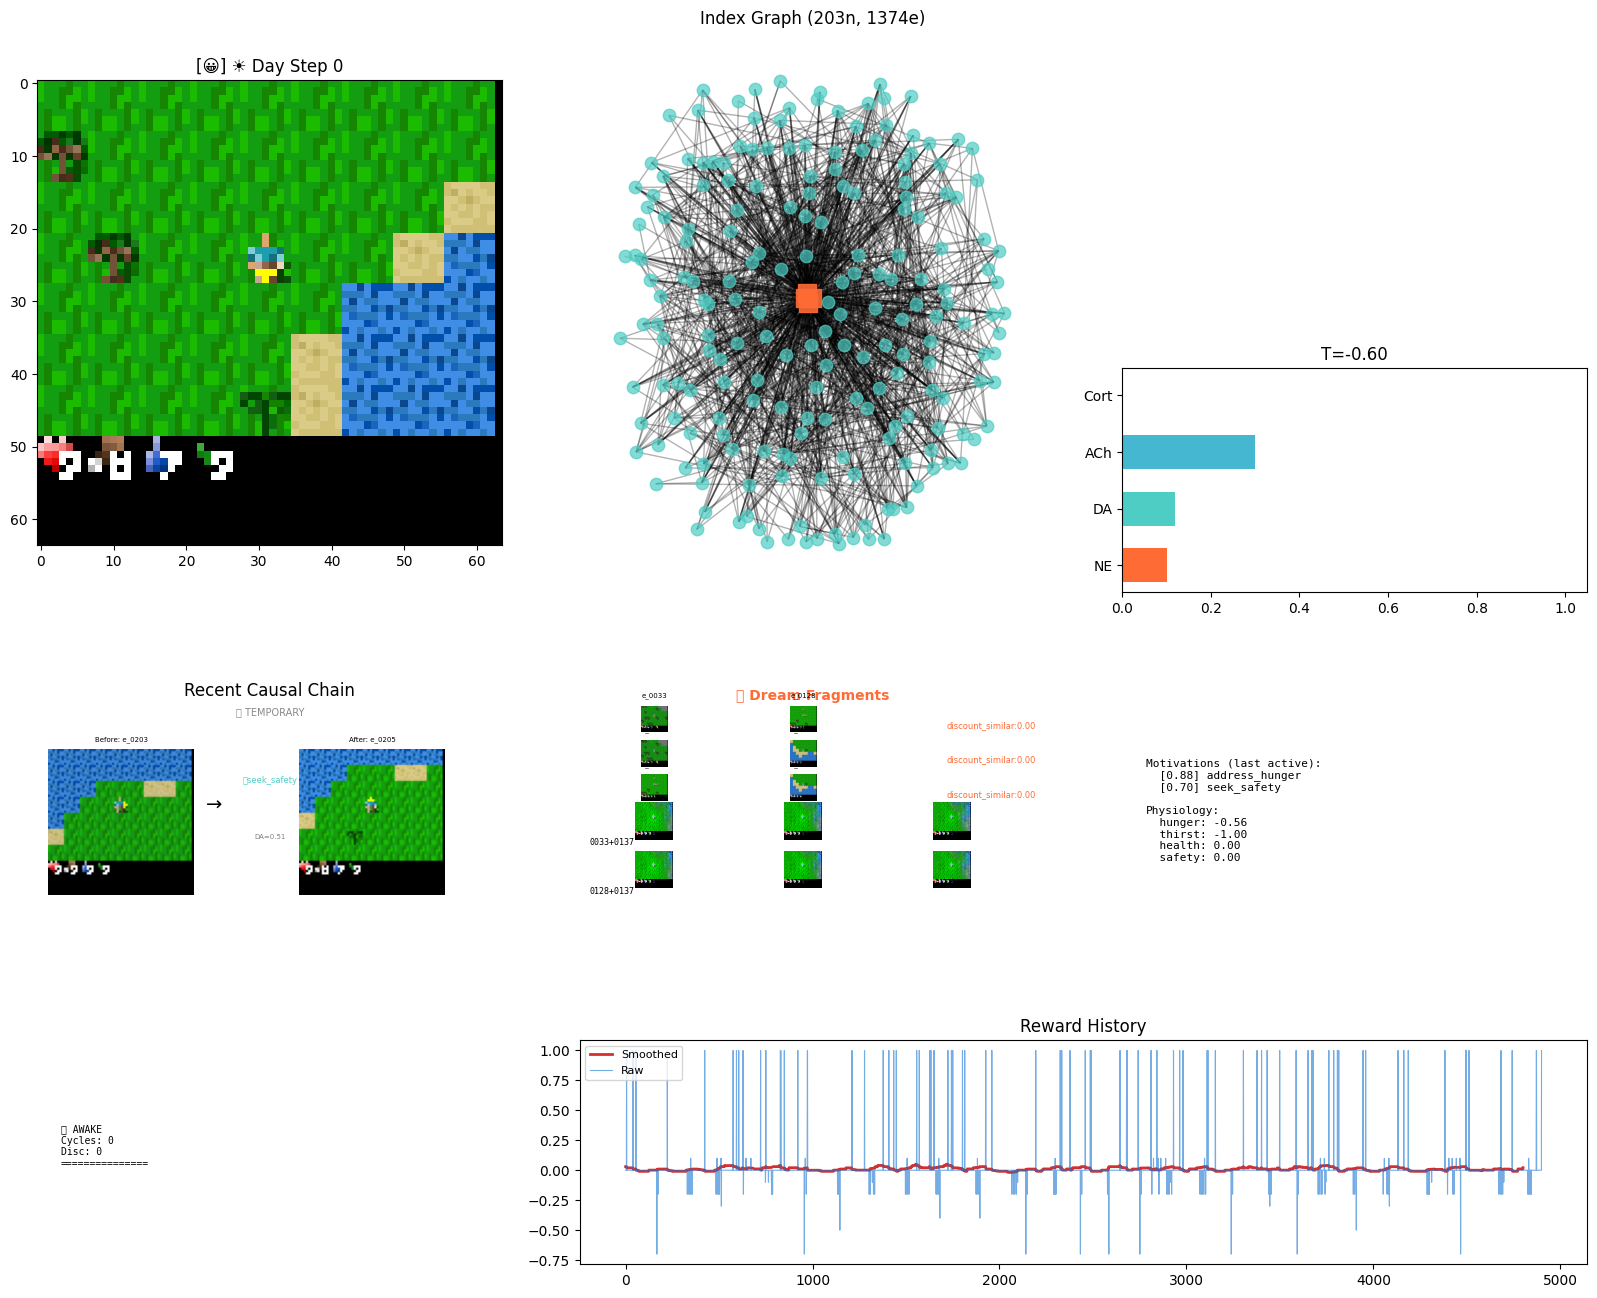

[DEBUG] info keys: ['inventory', 'achievements', 'discount', 'semantic', 'player_pos', 'reward']
[DEBUG] causal_chains=0, cortex=True, has_axis=True
Step 0: AGI=0.00, Random=0.00, PPO=0.00
  🏆 AGI current achievements: 0/22 (0.0%)
  🎖️ Lifetime best: 0/22
  🏆 Achievement unlocked: collect_sapling!
  🎖️ New record! Best single-life achievements: 1/22
  📊 Current achievements: 1/22
  ⏳ Chain TEMPORARY: trace_0003 → 🎯general → trace_0007
  🏆 Achievement unlocked: place_plant!
  🎖️ New record! Best single-life achievements: 2/22
  📊 Current achievements: 2/22

  💤 Sleep cycle 1 (consolidating 5 times)...
    🧠 Available memory images: 10 (cortex total: 10)
    💡 Stored 23 new associations (filtered from 30 raw)
    🛌 Remaining consolidations: 4
    📊 Current index chain count: 26
    🧠 Available memory images: 10 (cortex total: 10)
    💡 Stored 28 new associations (filtered from 30 raw)
    🛌 Remaining consolidations: 3
    📊 Current index chain count: 42
    🧠 Available memory images: 10 

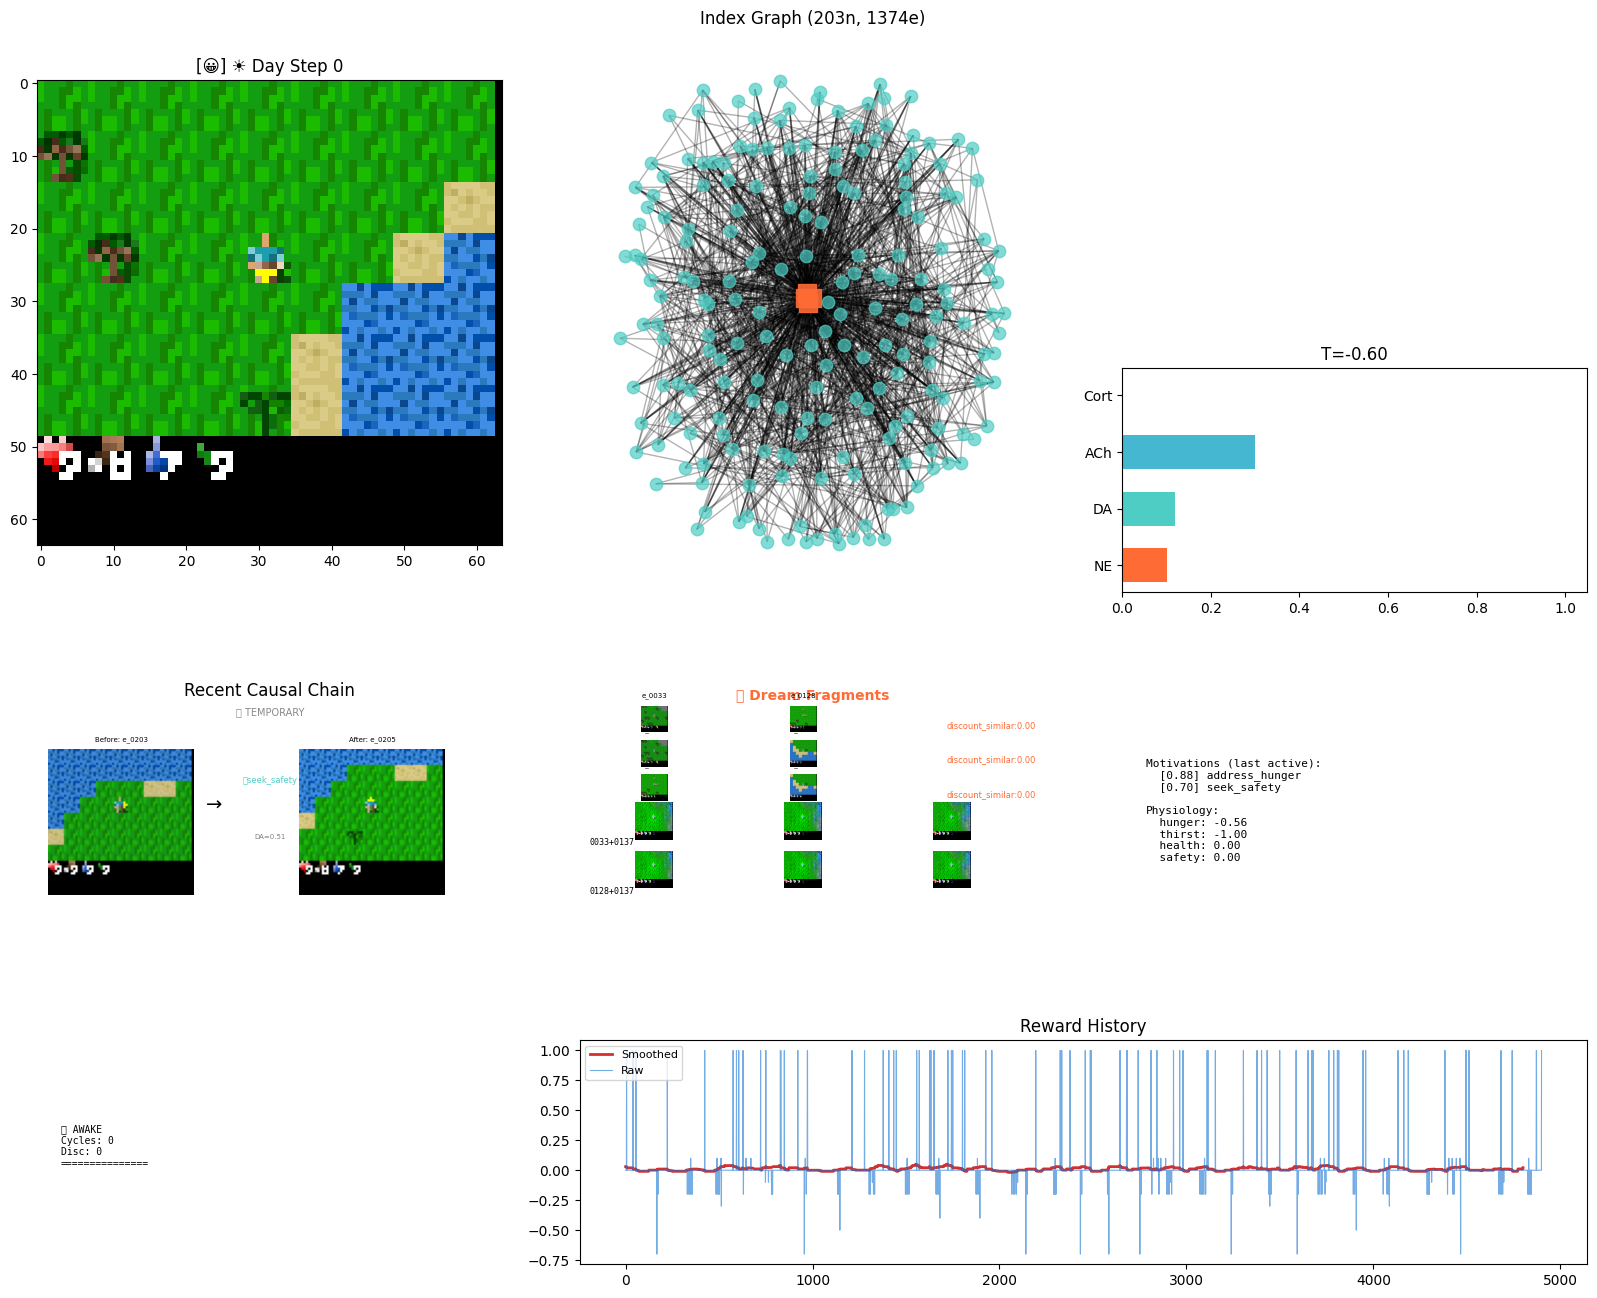

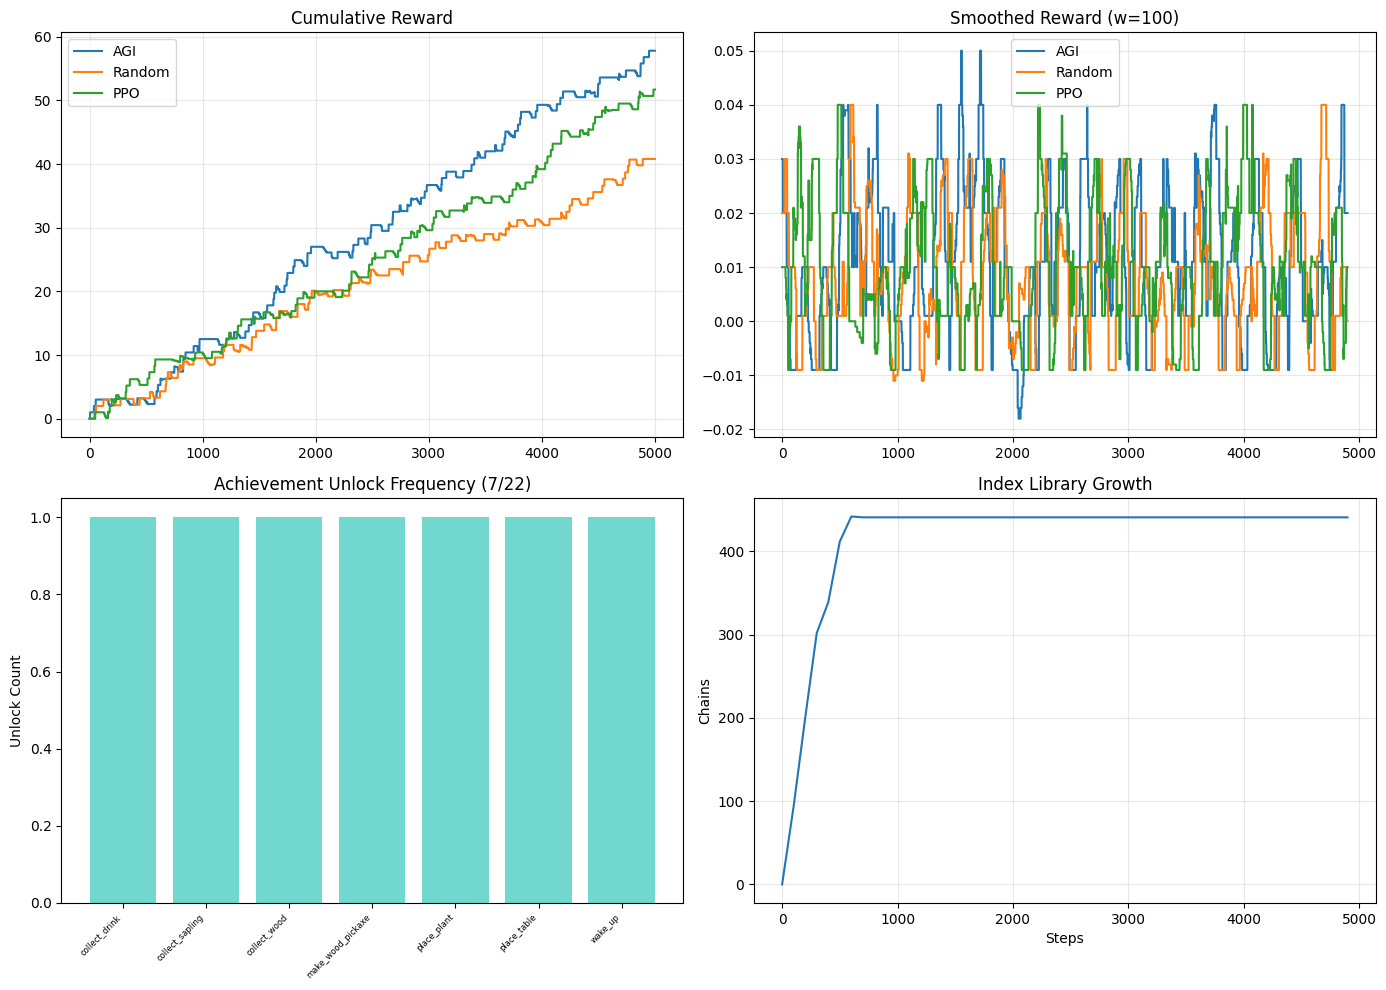

In [162]:
# ============================================================================
# Run Experiment
# ============================================================================

config = Config(
    total_steps=5000,
    use_pretrained_dit=False,
    feature_dim=64,
    max_memory_images=2000,
    recent_images_for_dream=10,
    render_interval=100,
    figsize=(20, 16),
    TOTAL_ACHIEVEMENTS=22,
)

histories, agents, chain_counts = run_experiment(config)

stat = statistics_show(histories, agents, chain_counts)



In [156]:
# 需要展示一下曲线变化 死之前走的总步数

In [ ]:
# ============================================================================
# Clean up previous session state
# ============================================================================
import gc
import shutil
import os

# Clear PyTorch GPU cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

# Force garbage collection
gc.collect()

# Clear Hugging Face cache (if any)
hf_cache = os.path.expanduser("~/.cache/huggingface")
if os.path.exists(hf_cache):
    shutil.rmtree(hf_cache)
    print("✓ Hugging Face cache cleared")

# Clear matplotlib figures
import matplotlib.pyplot as plt
plt.close('all')

print("✓ Previous session state cleaned")